# LIBRARY

In [1]:
%pip install scikit-plot -q
%pip install scipy -q

Note: you may need to restart the kernel to use updated packages.
Note: you may need to restart the kernel to use updated packages.


In [2]:
import numpy as np
import scipy
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt
from sklearn.preprocessing import LabelEncoder
from sklearn.model_selection import train_test_split
from sklearn.tree import DecisionTreeClassifier, plot_tree, DecisionTreeRegressor
from sklearn.model_selection import cross_val_score
from sklearn.model_selection import RandomizedSearchCV
from sklearn.model_selection import KFold
from sklearn.model_selection import StratifiedKFold
from scikitplot.metrics import plot_roc
from scikitplot.metrics import plot_precision_recall
from sklearn.tree._tree import TREE_LEAF
from sklearn.tree import plot_tree, DecisionTreeRegressor
import matplotlib.pyplot as plt
from sklearn.ensemble import RandomForestRegressor
from sklearn.model_selection import RandomizedSearchCV, KFold
import numpy as np
from sklearn.ensemble import RandomForestClassifier

In [3]:
from sklearn.metrics import (
    accuracy_score,
    f1_score,
    classification_report,
    confusion_matrix,
    roc_auc_score,
    mean_squared_error,
    mean_absolute_error, 
    r2_score
)

# IMPORT CONTROL DATA SET 

In [4]:
file_path = "../1.DATASET/CMI_V2_CONTROL.csv"
df=pd.read_csv(file_path)
df

,id,Basic_Demos-Age,Basic_Demos-Sex,CGAS-CGAS_Score,Physical-BMI,Physical-Height,Physical-Weight,BIA-BIA_BMR,Physical-HeartRate,Fitness_Endurance-Max_Stage,...,BIA-BIA_Frame_num,BIA-BIA_SMM,BIA-BIA_TBW,SDS-SDS_Total_T,PreInt_EduHx-computerinternet_hoursday,sii,Physical-MAP_CAL,FGC-FGC_CORE_CAL,FGC-FGC_GS_CAL,FGC-FGC_SR_CAL
0,1,9,0,NaN,14.035590,48.00,46.0,936.656,70.0,NaN,...,1.0,15.4107,27.0552,64.0,0.0,0.0,90.666667,8.000000,18.204545,11.000000
1,3,9,0,71.0,18.292347,56.00,81.6,1131.430,97.0,6.0,...,2.0,26.4798,45.9966,45.0,0.0,1.0,79.000000,23.000000,18.204545,7.000000
2,5,13,1,50.0,22.279952,59.50,112.2,1330.970,73.0,5.0,...,2.0,35.3804,63.1265,56.0,0.0,1.0,74.000000,18.000000,17.200000,10.500000
3,6,10,0,NaN,19.660760,55.00,84.6,1135.860,83.0,NaN,...,2.0,26.1957,47.2211,40.0,3.0,0.0,136.333333,11.000000,16.840263,11.000000
4,7,10,1,65.0,16.861286,59.25,84.2,1180.040,90.0,5.0,...,2.0,28.7680,50.4767,55.0,2.0,0.0,86.000000,14.662915,11.850000,7.682875
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
1852,3952,15,0,40.0,26.364710,70.50,186.4,1719.310,74.0,5.0,...,3.0,54.2027,91.4887,90.0,3.0,1.0,117.333333,23.714789,26.417470,8.527654
1853,3953,8,0,65.0,17.139810,52.50,67.2,1035.270,65.0,NaN,...,1.0,20.2645,36.7181,58.0,2.0,0.0,77.333333,10.568299,18.526452,9.000000
1854,3954,7,1,NaN,13.927006,48.50,46.6,966.287,75.0,5.0,...,1.0,18.0937,30.0453,67.0,0.0,1.0,78.333333,9.540221,18.909726,8.750000
1855,3955,13,0,60.0,16.362460,59.50,82.4,1206.880,70.0,NaN,...,1.0,29.7790,52.8320,50.0,1.0,1.0,82.000000,26.000000,18.950000,8.500000


In [5]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1857 entries, 0 to 1856
Data columns (total 32 columns):
 #   Column                                  Non-Null Count  Dtype  
---  ------                                  --------------  -----  
 0   id                                      1857 non-null   int64  
 1   Basic_Demos-Age                         1857 non-null   int64  
 2   Basic_Demos-Sex                         1857 non-null   int64  
 3   CGAS-CGAS_Score                         1679 non-null   float64
 4   Physical-BMI                            1857 non-null   float64
 5   Physical-Height                         1857 non-null   float64
 6   Physical-Weight                         1857 non-null   float64
 7   BIA-BIA_BMR                             1856 non-null   float64
 8   Physical-HeartRate                      1853 non-null   float64
 9   Fitness_Endurance-Max_Stage             1206 non-null   float64
 10  FGC-FGC_TL                              1708 non-null   floa

# Data Cleaning

## Removing useless variables

In [6]:
column2drop = ['id']
df.drop(column2drop, axis=1, inplace=True)

In [7]:
df.head()

,Basic_Demos-Age,Basic_Demos-Sex,CGAS-CGAS_Score,Physical-BMI,Physical-Height,Physical-Weight,BIA-BIA_BMR,Physical-HeartRate,Fitness_Endurance-Max_Stage,FGC-FGC_TL,...,BIA-BIA_Frame_num,BIA-BIA_SMM,BIA-BIA_TBW,SDS-SDS_Total_T,PreInt_EduHx-computerinternet_hoursday,sii,Physical-MAP_CAL,FGC-FGC_CORE_CAL,FGC-FGC_GS_CAL,FGC-FGC_SR_CAL
0,9,0,NaN,14.035590,48.00,46.0,936.656,70.0,NaN,3.0,...,1.0,15.4107,27.0552,64.0,0.0,0.0,90.666667,8.000000,18.204545,11.000000
1,9,0,71.0,18.292347,56.00,81.6,1131.430,97.0,6.0,7.0,...,2.0,26.4798,45.9966,45.0,0.0,1.0,79.000000,23.000000,18.204545,7.000000
2,13,1,50.0,22.279952,59.50,112.2,1330.970,73.0,5.0,8.0,...,2.0,35.3804,63.1265,56.0,0.0,1.0,74.000000,18.000000,17.200000,10.500000
3,10,0,NaN,19.660760,55.00,84.6,1135.860,83.0,NaN,11.0,...,2.0,26.1957,47.2211,40.0,3.0,0.0,136.333333,11.000000,16.840263,11.000000
4,10,1,65.0,16.861286,59.25,84.2,1180.040,90.0,5.0,4.0,...,2.0,28.7680,50.4767,55.0,2.0,0.0,86.000000,14.662915,11.850000,7.682875


In [8]:
df.columns

Index(['Basic_Demos-Age', 'Basic_Demos-Sex', 'CGAS-CGAS_Score', 'Physical-BMI',
       'Physical-Height', 'Physical-Weight', 'BIA-BIA_BMR',
       'Physical-HeartRate', 'Fitness_Endurance-Max_Stage', 'FGC-FGC_TL',
       'BIA-BIA_Activity_Level_num', 'BIA-BIA_BMI', 'BIA-BIA_BMC',
       'BIA-BIA_DEE', 'BIA-BIA_ECW', 'BIA-BIA_ICW', 'BIA-BIA_FFMI',
       'BIA-BIA_FFM', 'BIA-BIA_FMI', 'BIA-BIA_Fat', 'BIA-BIA_LST',
       'BIA-BIA_Frame_num', 'BIA-BIA_SMM', 'BIA-BIA_TBW', 'SDS-SDS_Total_T',
       'PreInt_EduHx-computerinternet_hoursday', 'sii', 'Physical-MAP_CAL',
       'FGC-FGC_CORE_CAL', 'FGC-FGC_GS_CAL', 'FGC-FGC_SR_CAL'],
      dtype='object')

# TARGET VARIABLES

## TARGET VARIABLE Physical-Height

In [9]:
df_height = df[[ 'Physical-BMI','Physical-Height', 'Physical-Weight']].copy()


In [10]:
df_height.isnull().sum()

Physical-BMI       0
Physical-Height    0
Physical-Weight    0
dtype: int64

In [11]:
df_height[df_height['Physical-Height']==0]

,Physical-BMI,Physical-Height,Physical-Weight


### Partitioning

In [12]:
attributes = [col for col in df_height.columns if col != 'Physical-Height']
X = df_height[attributes].values
y = np.array(df_height['Physical-Height'])

In [13]:
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.25, random_state=0)


In [14]:
print(X_train.shape, X_test.shape, y_train.shape, y_test.shape)

(1392, 2) (465, 2) (1392,) (465,)


In [15]:
df_height.shape

(1857, 3)

### Randomized Search

In [16]:
# options for scoring
#scoring='neg_mean_squared_error'      # most common, minimizes large errors
#scoring='neg_mean_absolute_error'     # more robust to outliers
#scoring='neg_root_mean_squared_error' # directly in target units
#scoring='r2'                          # maximizes explained variance

In [17]:
param_list = {
    'max_depth': [None] + list(np.arange(2, 50)),
    'min_samples_split': [0.001, 0.002, 0.01, 0.05, 0.1, 0.2],
    'min_samples_leaf': [5, 10, 20, 30, 50, 100, 150],
    'criterion': ['squared_error', 'absolute_error', 'friedman_mse']  
}

dt_reg_height = DecisionTreeRegressor()  

random_search = RandomizedSearchCV(
    DecisionTreeRegressor(),    
    param_distributions=param_list,
    cv=KFold(n_splits=5, shuffle=True, random_state=0), 
    scoring='neg_mean_squared_error' ,   
    n_jobs=-1,
    refit=True,
    n_iter=300,
)

random_search.fit(X_train, y_train)
dt_reg_height = random_search.best_estimator_

In [18]:
print(random_search.best_params_, random_search.best_score_)

{'min_samples_split': 0.001, 'min_samples_leaf': 5, 'max_depth': 15, 'criterion': 'friedman_mse'} -1.4502905945660727


In [19]:
dt_reg_height = random_search.best_estimator_
dt_reg_height.fit(X_train, y_train)

DecisionTreeRegressor(criterion='friedman_mse', max_depth=15,
                      min_samples_leaf=5, min_samples_split=0.001)

In [20]:
y_pred = dt_reg_height.predict(X_test)

print(f"RMSE : {np.sqrt(mean_squared_error(y_test, y_pred)):.4f}") # Typical error
print(f"MAE  : {mean_absolute_error(y_test, y_pred):.4f}")  #Average Error
print(f"MSE  : {mean_squared_error(y_test, y_pred):.4f}")  #Average Error
print(f"R²   : {r2_score(y_test, y_pred):.4f}") # variance in the target variable

RMSE : 1.0631
MAE  : 0.7167
MSE  : 1.1302
R²   : 0.9785


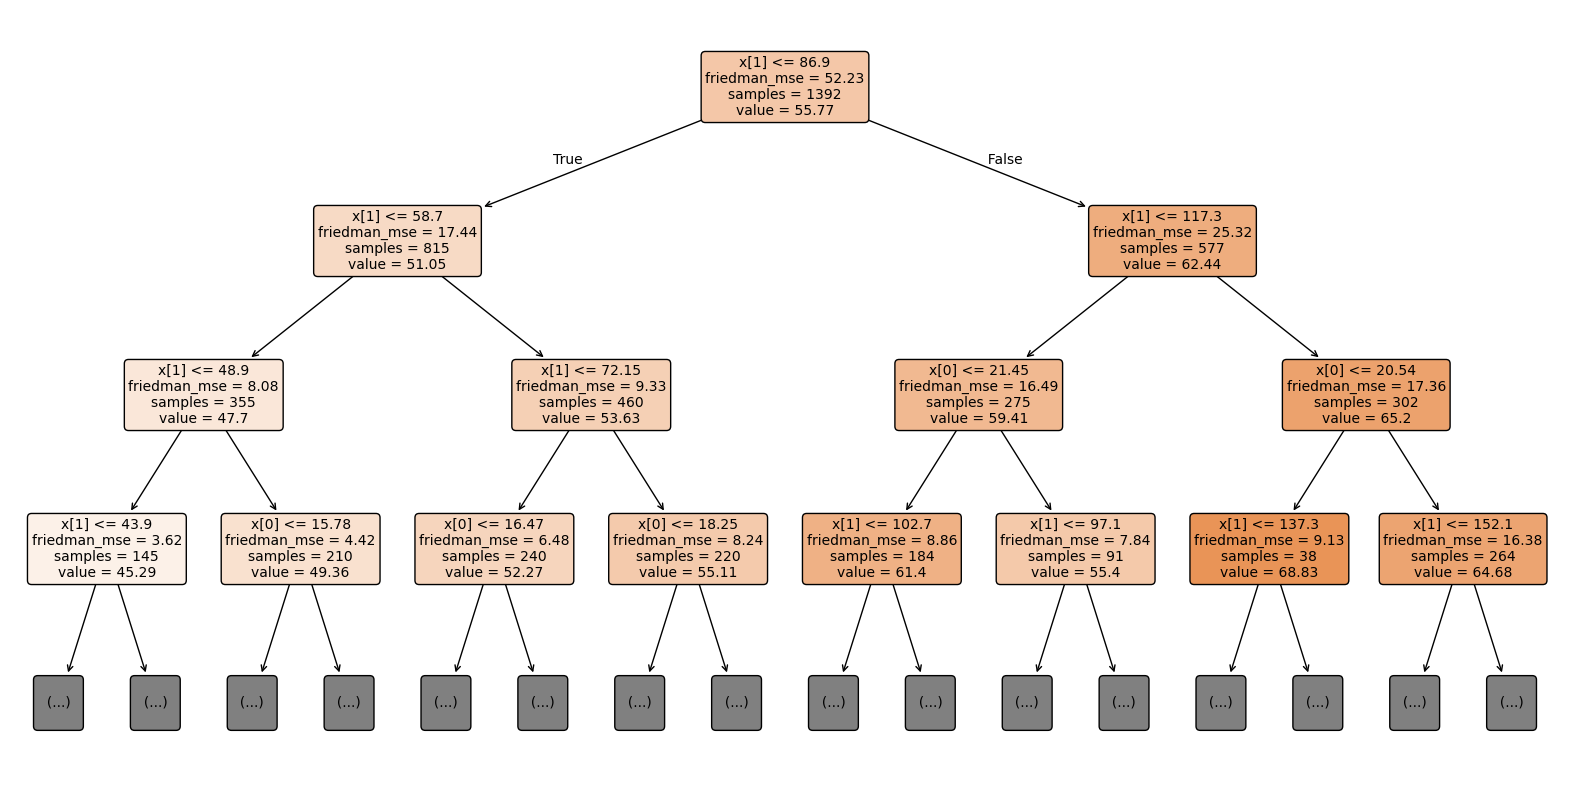

In [21]:
plt.figure(figsize=(20, 10))

plot_tree(
    dt_reg_height,
    filled=True,
    rounded=True,
    fontsize=10,
    precision=2,
    max_depth = 3
)

plt.show()

Idx | Actual | Predicted | Error
----------------------------------------
  77 | 41.5000 |   48.3333 | 6.8333
 311 | 49.0000 |   55.5071 | 6.5071
  24 | 77.5000 |   71.7000 | 5.8000
 366 | 70.5000 |   66.7000 | 3.8000
 235 | 70.0000 |   73.6786 | 3.6786
 272 | 70.0000 |   73.6786 | 3.6786
  99 | 64.0000 |   60.8000 | 3.2000
  44 | 70.5000 |   67.4000 | 3.1000
 415 | 70.5000 |   67.4000 | 3.1000
 210 | 50.0000 |   52.8600 | 2.8600


C:\Users\paula\AppData\Local\Temp\ipykernel_13496\1016786874.py:15: UserWarning: No artists with labels found to put in legend.  Note that artists whose label start with an underscore are ignored when legend() is called with no argument.
  plt.legend()


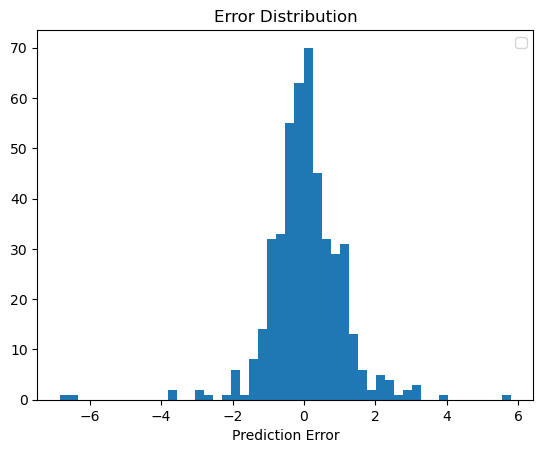

In [22]:
errors = np.abs(y_test - y_pred)

# Top 10 worst predictions
worst_indices = np.argsort(errors)[-10:][::-1]

print("Idx | Actual | Predicted | Error")
print("-" * 40)
for i in worst_indices:
    print(f"{i:4d} | {y_test[i]:7.4f} | {y_pred[i]:9.4f} | {errors[i]:.4f}")

# Error distribution plot
plt.hist(y_test - y_pred, bins=50)
plt.xlabel('Prediction Error')
plt.title('Error Distribution')
plt.legend()
plt.show()

### Feature Importance

In [23]:
zipped = zip(attributes, dt_reg_height.feature_importances_)
zipped = sorted(zipped, key=lambda x: x[1], reverse=True)
for col, imp in zipped:
    print(col, imp)

Physical-Weight 0.8721327800240896
Physical-BMI 0.12786721997591036


## TARGET VARIABLE BIA-BIA_TBW

In [24]:
df_BIA_TBW = df[['BIA-BIA_ECW', 'BIA-BIA_ICW','BIA-BIA_TBW']].copy()



In [25]:
#df_BIA_TBW=df_BIA_TBW.dropna(subset=['BIA-BIA_FFMI'])

In [26]:
df_BIA_TBW.isnull().sum()

BIA-BIA_ECW    0
BIA-BIA_ICW    0
BIA-BIA_TBW    0
dtype: int64

In [27]:
df_BIA_TBW[df_BIA_TBW['BIA-BIA_TBW']==0]

,BIA-BIA_ECW,BIA-BIA_ICW,BIA-BIA_TBW


### Partitioning

In [28]:
attributes = [col for col in df_BIA_TBW.columns if col != 'BIA-BIA_TBW']
X = df_BIA_TBW[attributes].values
y = np.array(df_BIA_TBW['BIA-BIA_TBW'])

In [29]:
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.25, random_state=0)


In [30]:
print(X_train.shape, X_test.shape, y_train.shape, y_test.shape)

(1392, 2) (465, 2) (1392,) (465,)


In [31]:
df_BIA_TBW.shape

(1857, 3)

### Randomized Search

In [32]:
# options for scoring
#scoring='neg_mean_squared_error'      # most common, minimizes large errors
#scoring='neg_mean_absolute_error'     # more robust to outliers
#scoring='neg_root_mean_squared_error' # directly in target units
#scoring='r2'                          # maximizes explained variance

In [33]:
param_list = {
    'max_depth': [None] + list(np.arange(2, 50)),
    'min_samples_split': [0.001, 0.002, 0.01, 0.05, 0.1, 0.2],
    'min_samples_leaf': [5, 10, 20, 30, 50, 100, 150],
    'criterion': ['squared_error', 'absolute_error', 'friedman_mse']  
}

dt_reg_TBW = DecisionTreeRegressor()  

random_search = RandomizedSearchCV(
    DecisionTreeRegressor(),    
    param_distributions=param_list,
    cv=KFold(n_splits=5, shuffle=True, random_state=0), 
    scoring='neg_mean_squared_error' ,   
    n_jobs=-1,
    refit=True,
    n_iter=300,
)

random_search.fit(X_train, y_train)
dt_reg_TBW = random_search.best_estimator_

In [34]:
print(random_search.best_params_, random_search.best_score_)

{'min_samples_split': 0.001, 'min_samples_leaf': 5, 'max_depth': 30, 'criterion': 'friedman_mse'} -1.5664493740721024


In [35]:
dt_reg_TBW = random_search.best_estimator_
dt_reg_TBW.fit(X_train, y_train)

DecisionTreeRegressor(criterion='friedman_mse', max_depth=30,
                      min_samples_leaf=5, min_samples_split=0.001)

In [36]:
y_pred = dt_reg_TBW.predict(X_test)

print(f"RMSE : {np.sqrt(mean_squared_error(y_test, y_pred)):.4f}") # Typical error
print(f"MAE  : {mean_absolute_error(y_test, y_pred):.4f}")  #Average Error
print(f"MSE  : {mean_squared_error(y_test, y_pred):.4f}")  #Average Error
print(f"R²   : {r2_score(y_test, y_pred):.4f}") # variance in the target variable

RMSE : 1.0219
MAE  : 0.6373
MSE  : 1.0443
R²   : 0.9969


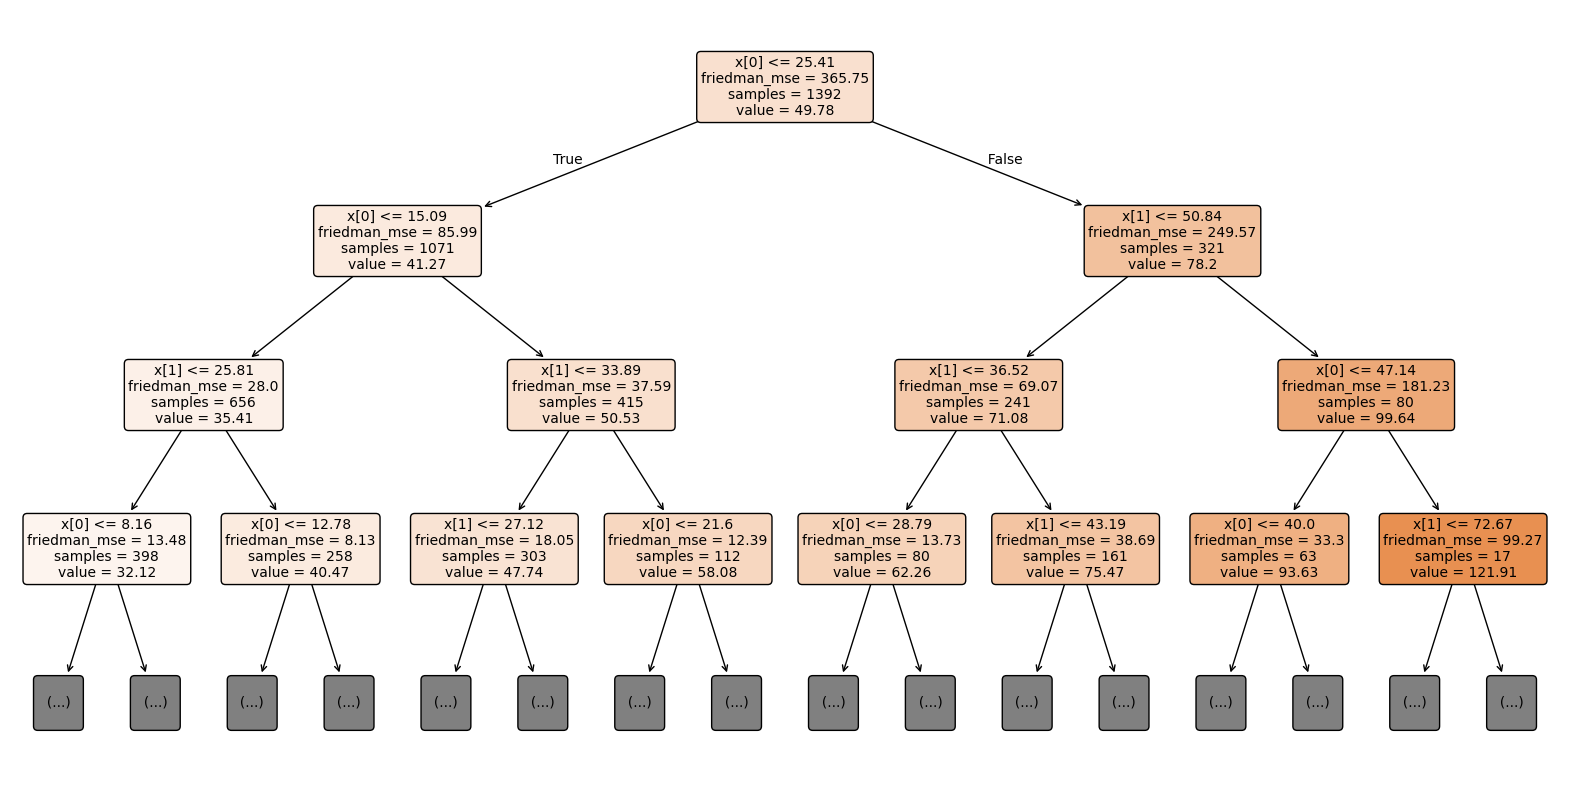

In [37]:
plt.figure(figsize=(20, 10))

plot_tree(
    dt_reg_TBW,
    filled=True,
    rounded=True,
    fontsize=10,
    precision=2,
    max_depth = 3
)

plt.show()

Idx | Actual | Predicted | Error
----------------------------------------
 372 | 113.7130 |  120.2422 | 6.5292
  24 | 125.9560 |  120.2422 | 5.7138
 405 | 22.8800 |   28.0992 | 5.2192
 196 | 81.5263 |   86.3486 | 4.8223
 186 | 60.2056 |   56.1244 | 4.0812
 121 | 107.0920 |  103.3416 | 3.7504
 145 | 83.5786 |   80.0303 | 3.5483
 162 | 74.0409 |   77.4125 | 3.3716
  93 | 123.5600 |  120.2422 | 3.3178
 366 | 132.1710 |  135.4846 | 3.3136


C:\Users\paula\AppData\Local\Temp\ipykernel_13496\1016786874.py:15: UserWarning: No artists with labels found to put in legend.  Note that artists whose label start with an underscore are ignored when legend() is called with no argument.
  plt.legend()


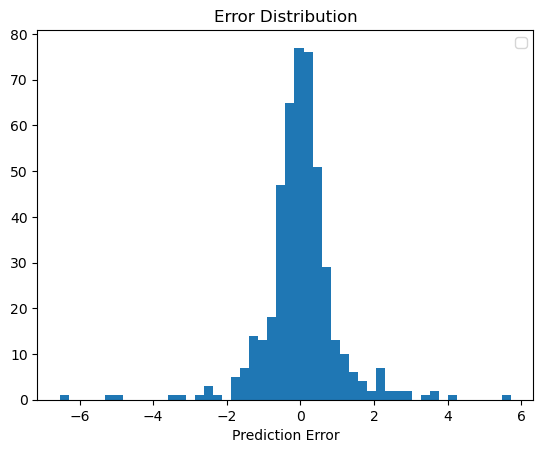

In [38]:
errors = np.abs(y_test - y_pred)

# Top 10 worst predictions
worst_indices = np.argsort(errors)[-10:][::-1]

print("Idx | Actual | Predicted | Error")
print("-" * 40)
for i in worst_indices:
    print(f"{i:4d} | {y_test[i]:7.4f} | {y_pred[i]:9.4f} | {errors[i]:.4f}")

# Error distribution plot
plt.hist(y_test - y_pred, bins=50)
plt.xlabel('Prediction Error')
plt.title('Error Distribution')
plt.legend()
plt.show()

### Feature Importance

In [39]:
zipped = zip(attributes, dt_reg_TBW.feature_importances_)
zipped = sorted(zipped, key=lambda x: x[1], reverse=True)
for col, imp in zipped:
    print(col, imp)

BIA-BIA_ECW 0.8262170259642088
BIA-BIA_ICW 0.1737829740357913


## TARGET VARIABLE BIA-BIA_Fat

In [40]:
df_BIA_Fat = df[['Physical-Weight', 
                'Physical-Height','BIA-BIA_FMI',
                'BIA-BIA_Fat'                          
]].copy()



In [41]:
#df_BIA_Fat=df_BIA_Fat.dropna(subset=['BIA-BIA_FFMI','Physical-HeartRate'])

In [42]:
df_BIA_Fat.isnull().sum()

Physical-Weight    0
Physical-Height    0
BIA-BIA_FMI        0
BIA-BIA_Fat        0
dtype: int64

### Partitioning

In [43]:
attributes = [col for col in df_BIA_Fat.columns if col != 'BIA-BIA_Fat']
X = df_BIA_Fat[attributes].values
y = np.array(df_BIA_Fat['BIA-BIA_Fat'])

In [44]:
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.25, random_state=0)


In [45]:
print(X_train.shape, X_test.shape, y_train.shape, y_test.shape)

(1392, 3) (465, 3) (1392,) (465,)


In [46]:
df_BIA_Fat.shape

(1857, 4)

### Randomized Search

In [47]:
# options for scoring
#scoring='neg_mean_squared_error'      # most common, minimizes large errors
#scoring='neg_mean_absolute_error'     # more robust to outliers
#scoring='neg_root_mean_squared_error' # directly in target units
#scoring='r2'                          # maximizes explained variance

In [48]:
param_list = {
    'max_depth': [None] + list(np.arange(2, 50)),
    'min_samples_split': [0.001, 0.002, 0.01, 0.05, 0.1, 0.2],
    'min_samples_leaf': [5, 10, 20, 30, 50, 100, 150],
    'criterion': ['squared_error', 'absolute_error', 'friedman_mse']  
}

dt_reg_FAT = DecisionTreeRegressor()  

random_search = RandomizedSearchCV(
    DecisionTreeRegressor(),    
    param_distributions=param_list,
    cv=KFold(n_splits=5, shuffle=True, random_state=0), 
    scoring='neg_mean_squared_error' ,   
    n_jobs=-1,
    refit=True,
    n_iter=300,
)

random_search.fit(X_train, y_train)
dt_reg_FAT = random_search.best_estimator_

In [49]:
print(random_search.best_params_, random_search.best_score_)

{'min_samples_split': 0.002, 'min_samples_leaf': 5, 'max_depth': 26, 'criterion': 'absolute_error'} -8.508562210184255


In [50]:
dt_reg_FAT = random_search.best_estimator_
dt_reg_FAT.fit(X_train, y_train)

DecisionTreeRegressor(criterion='absolute_error', max_depth=26,
                      min_samples_leaf=5, min_samples_split=0.002)

In [51]:
y_pred = dt_reg_FAT.predict(X_test)

print(f"RMSE : {np.sqrt(mean_squared_error(y_test, y_pred)):.4f}") # Typical error
print(f"MAE  : {mean_absolute_error(y_test, y_pred):.4f}")  #Average Error
print(f"MSE  : {mean_squared_error(y_test, y_pred):.4f}")  #Average Error
print(f"R²   : {r2_score(y_test, y_pred):.4f}") # variance in the target variable

RMSE : 2.1463
MAE  : 1.1946
MSE  : 4.6065
R²   : 0.9866


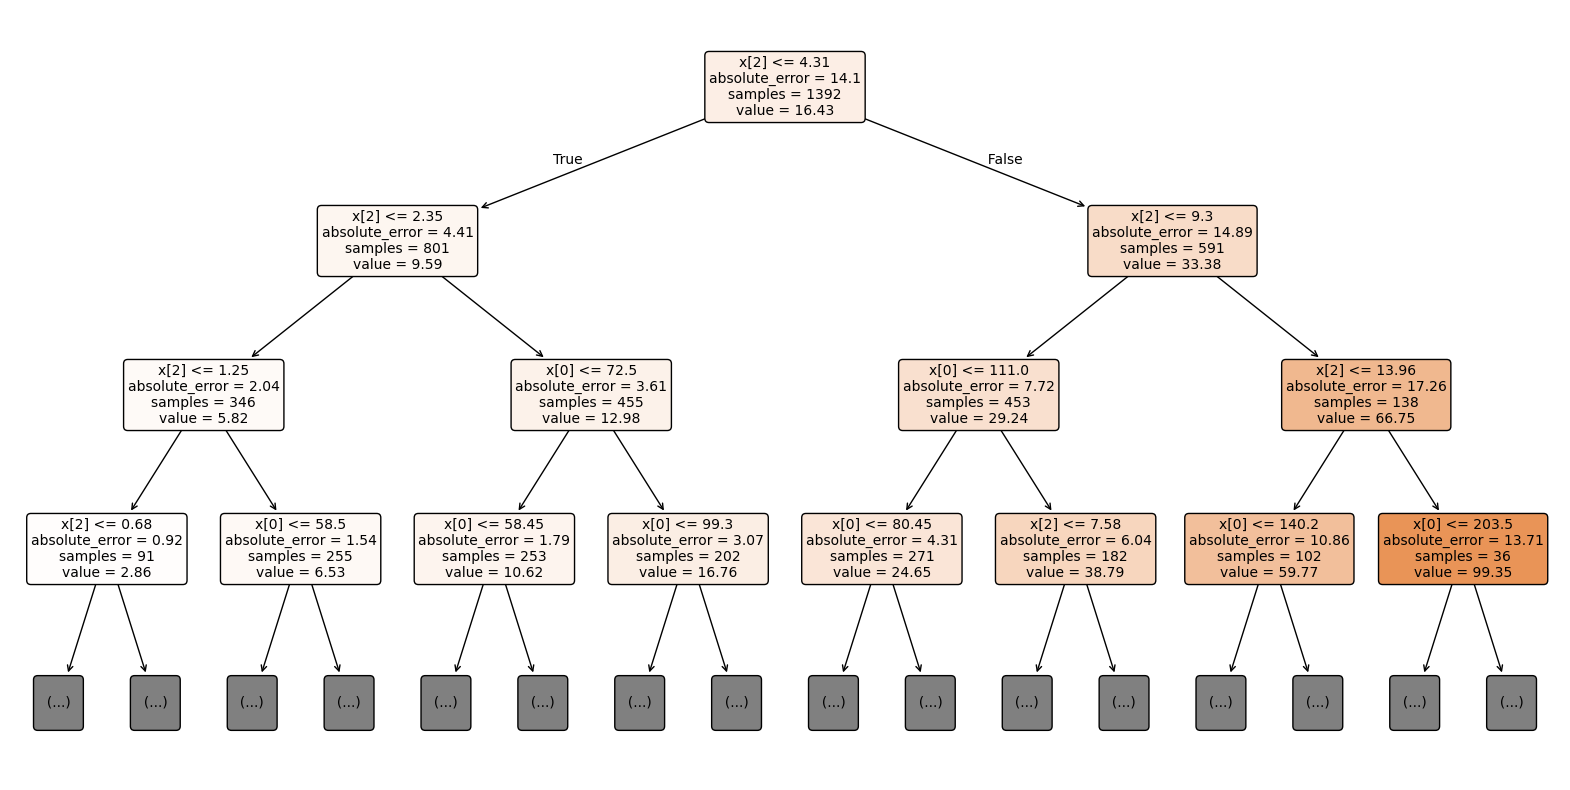

In [52]:
plt.figure(figsize=(20, 10))

plot_tree(
    dt_reg_FAT,
    filled=True,
    rounded=True,
    fontsize=10,
    precision=2,
    max_depth = 3
)

plt.show()

Idx | Actual | Predicted | Error
----------------------------------------
 366 | 126.0100 |  105.8120 | 20.1980
 311 | 58.6013 |   75.4429 | 16.8416
 145 | 108.8070 |  116.9160 | 8.1090
 127 | 81.4070 |   88.6792 | 7.2722
 130 | 57.1916 |   50.0139 | 7.1777
 393 | 56.1160 |   49.2732 | 6.8428
  98 | 42.4451 |   35.7149 | 6.7302
   9 | 71.3179 |   64.5942 | 6.7237
  18 | 39.2171 |   45.5311 | 6.3139
 293 | 75.8225 |   69.7108 | 6.1117


C:\Users\paula\AppData\Local\Temp\ipykernel_13496\1016786874.py:15: UserWarning: No artists with labels found to put in legend.  Note that artists whose label start with an underscore are ignored when legend() is called with no argument.
  plt.legend()


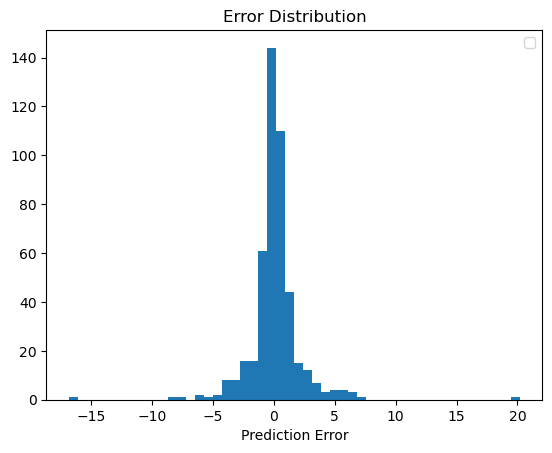

In [53]:
errors = np.abs(y_test - y_pred)

# Top 10 worst predictions
worst_indices = np.argsort(errors)[-10:][::-1]

print("Idx | Actual | Predicted | Error")
print("-" * 40)
for i in worst_indices:
    print(f"{i:4d} | {y_test[i]:7.4f} | {y_pred[i]:9.4f} | {errors[i]:.4f}")

# Error distribution plot
plt.hist(y_test - y_pred, bins=50)
plt.xlabel('Prediction Error')
plt.title('Error Distribution')
plt.legend()
plt.show()

### Feature Importance

In [54]:
zipped = zip(attributes, dt_reg_FAT.feature_importances_)
zipped = sorted(zipped, key=lambda x: x[1], reverse=True)
for col, imp in zipped:
    print(col, imp)

BIA-BIA_FMI 0.7620764553831256
Physical-Weight 0.2159640819646583
Physical-Height 0.021959462652216117


## TARGET VARIABLE BIA-BIA_DEE

In [238]:
df_BIA_DEE = df[[
    'BIA-BIA_DEE',
    'BIA-BIA_BMR',                  
    'BIA-BIA_Activity_Level_num',   
    'Basic_Demos-Sex',
    'BIA-BIA_TBW'         
]]



In [239]:
df_BIA_DEE=df_BIA_DEE.dropna(subset=['BIA-BIA_DEE','BIA-BIA_BMR'])

In [240]:
df_BIA_DEE.isnull().sum()

BIA-BIA_DEE                   0
BIA-BIA_BMR                   0
BIA-BIA_Activity_Level_num    0
Basic_Demos-Sex               0
BIA-BIA_TBW                   0
dtype: int64

### Partitioning

In [241]:
attributes = [col for col in df_BIA_DEE.columns if col != 'BIA-BIA_DEE']
X = df_BIA_DEE[attributes].values
y = np.array(df_BIA_DEE['BIA-BIA_DEE'])

In [242]:
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.25, random_state=0)


In [243]:
print(X_train.shape, X_test.shape, y_train.shape, y_test.shape)

(1392, 4) (464, 4) (1392,) (464,)


In [244]:
df_BIA_DEE.shape

(1856, 5)

### Randomized Search

In [245]:
# options for scoring
#scoring='neg_mean_squared_error'      # most common, minimizes large errors
#scoring='neg_mean_absolute_error'     # more robust to outliers
#scoring='neg_root_mean_squared_error' # directly in target units
#scoring='r2'                          # maximizes explained variance

In [246]:
param_list = {
    'max_depth': [None] + list(np.arange(2, 50)),
    'min_samples_split': [0.001, 0.002, 0.01, 0.05, 0.1, 0.2],
    'min_samples_leaf': [5, 10, 20, 30, 50, 100, 150],
    'criterion': ['squared_error', 'absolute_error', 'friedman_mse']  
}

dt_reg_DEE = DecisionTreeRegressor()  

random_search = RandomizedSearchCV(
    DecisionTreeRegressor(),    
    param_distributions=param_list,
    cv=KFold(n_splits=5, shuffle=True, random_state=0), 
    scoring='neg_mean_squared_error' ,   
    n_jobs=-1,
    refit=True,
    n_iter=300,
)

random_search.fit(X_train, y_train)
dt_reg_DEE = random_search.best_estimator_

In [247]:
print(random_search.best_params_, random_search.best_score_)

{'min_samples_split': 0.001, 'min_samples_leaf': 5, 'max_depth': 29, 'criterion': 'friedman_mse'} -6274.7125695297045


In [248]:
dt_reg_DEE = random_search.best_estimator_
dt_reg_DEE.fit(X_train, y_train)

DecisionTreeRegressor(criterion='friedman_mse', max_depth=29,
                      min_samples_leaf=5, min_samples_split=0.001)

In [249]:
y_pred = dt_reg_DEE.predict(X_test)

print(f"RMSE : {np.sqrt(mean_squared_error(y_test, y_pred)):.4f}") # Typical error
print(f"MAE  : {mean_absolute_error(y_test, y_pred):.4f}")  #Average Error
print(f"MSE  : {mean_squared_error(y_test, y_pred):.4f}")  #Average Error
print(f"R²   : {r2_score(y_test, y_pred):.4f}") # variance in the target variable

RMSE : 63.6947
MAE  : 28.0403
MSE  : 4057.0153
R²   : 0.9852


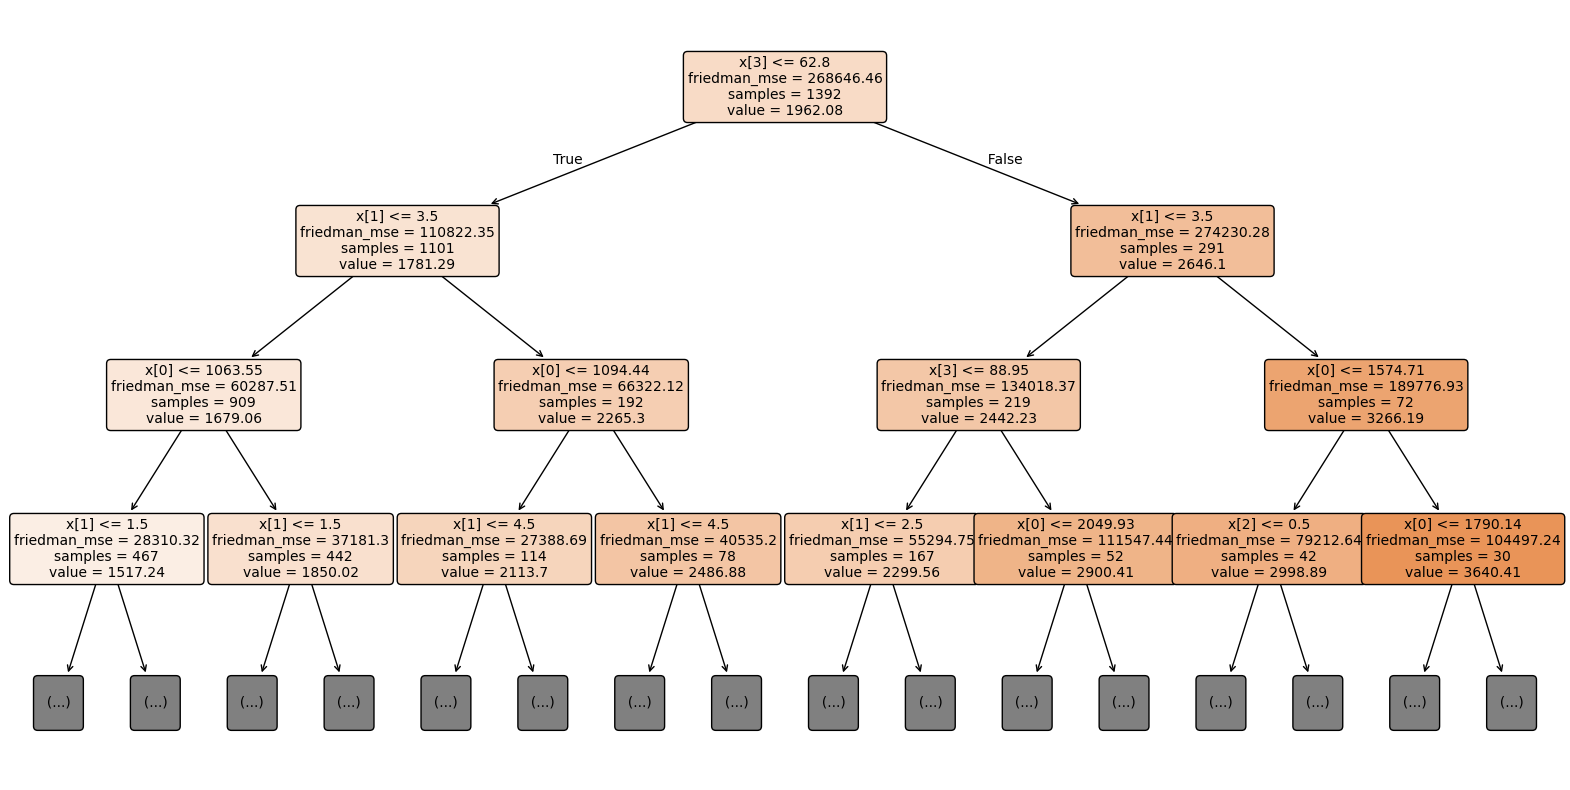

In [250]:
plt.figure(figsize=(20, 10))

plot_tree(
    dt_reg_DEE,
    filled=True,
    rounded=True,
    fontsize=10,
    precision=2,
    max_depth = 3
)

plt.show()

Idx | Actual | Predicted | Error
----------------------------------------
 136 | 2818.9700 | 3405.0000 | 586.0300
 140 | 4517.1300 | 4102.0500 | 415.0800
 363 | 4140.3100 | 3725.6486 | 414.6614
 223 | 3071.1600 | 3405.0000 | 333.8400
 194 | 3724.5800 | 3406.0443 | 318.5357
 404 | 3189.5500 | 2890.5350 | 299.0150
 232 | 3409.3500 | 3119.8700 | 289.4800
 247 | 2200.7500 | 2442.2844 | 241.5344
 361 | 1983.1900 | 2220.3233 | 237.1333
 175 | 2221.0200 | 2442.2844 | 221.2644


C:\Users\paula\AppData\Local\Temp\ipykernel_13496\1016786874.py:15: UserWarning: No artists with labels found to put in legend.  Note that artists whose label start with an underscore are ignored when legend() is called with no argument.
  plt.legend()


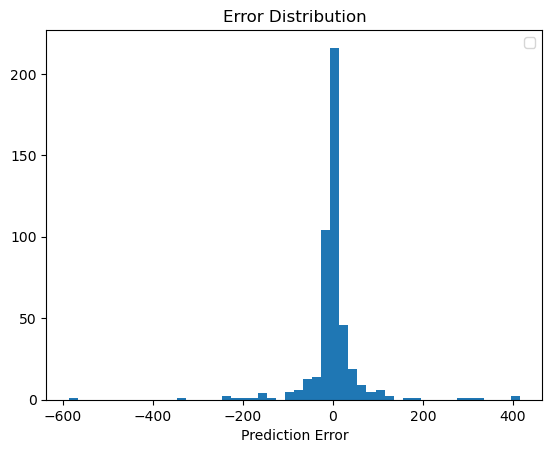

In [251]:
errors = np.abs(y_test - y_pred)

# Top 10 worst predictions
worst_indices = np.argsort(errors)[-10:][::-1]

print("Idx | Actual | Predicted | Error")
print("-" * 40)
for i in worst_indices:
    print(f"{i:4d} | {y_test[i]:7.4f} | {y_pred[i]:9.4f} | {errors[i]:.4f}")

# Error distribution plot
plt.hist(y_test - y_pred, bins=50)
plt.xlabel('Prediction Error')
plt.title('Error Distribution')
plt.legend()
plt.show()

### Feature Importance

In [252]:
zipped = zip(attributes, dt_reg_DEE.feature_importances_)
zipped = sorted(zipped, key=lambda x: x[1], reverse=True)
for col, imp in zipped:
    print(col, imp)

BIA-BIA_TBW 0.5200899450158954
BIA-BIA_Activity_Level_num 0.31690590052705814
BIA-BIA_BMR 0.1495190627271507
Basic_Demos-Sex 0.013485091729895699


## TARGET VARIABLE BIA-BIA_BMC

In [70]:
df_BIA_BMC = df[[
'BIA-BIA_LST' ,
'BIA-BIA_ICW',
'BIA-BIA_BMR' ,
'BIA-BIA_BMC'
]]





In [71]:
df_BIA_BMC=df_BIA_BMC.dropna(subset=['BIA-BIA_BMR'])

In [72]:
df_BIA_BMC.isnull().sum()

BIA-BIA_LST    0
BIA-BIA_ICW    0
BIA-BIA_BMR    0
BIA-BIA_BMC    0
dtype: int64

### Partitioning

In [73]:
attributes = [col for col in df_BIA_BMC.columns if col != 'BIA-BIA_BMC']
X = df_BIA_BMC[attributes].values
y = np.array(df_BIA_BMC['BIA-BIA_BMC'])

In [74]:
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.25, random_state=0)


In [75]:
print(X_train.shape, X_test.shape, y_train.shape, y_test.shape)

(1392, 3) (464, 3) (1392,) (464,)


In [76]:
df_BIA_BMC.shape

(1856, 4)

### Randomized Search

In [77]:
# options for scoring
#scoring='neg_mean_squared_error'      # most common, minimizes large errors
#scoring='neg_mean_absolute_error'     # more robust to outliers
#scoring='neg_root_mean_squared_error' # directly in target units
#scoring='r2'                          # maximizes explained variance

In [78]:
param_list = {
    'max_depth': [None] + list(np.arange(2, 50)),
    'min_samples_split': [0.001, 0.002, 0.01, 0.05, 0.1, 0.2],
    'min_samples_leaf': [5, 10, 20, 30, 50, 100, 150],
    'criterion': ['squared_error', 'absolute_error', 'friedman_mse']  
}

dt_reg_BMC = DecisionTreeRegressor()  

random_search = RandomizedSearchCV(
    DecisionTreeRegressor(),    
    param_distributions=param_list,
    cv=KFold(n_splits=5, shuffle=True, random_state=0), 
    scoring='neg_mean_squared_error' ,   
    n_jobs=-1,
    refit=True,
    n_iter=300,
)

random_search.fit(X_train, y_train)
dt_reg_BMC = random_search.best_estimator_

In [79]:
print(random_search.best_params_, random_search.best_score_)

{'min_samples_split': 0.002, 'min_samples_leaf': 5, 'max_depth': 47, 'criterion': 'friedman_mse'} -2.096019364201893


In [80]:
dt_reg_BMC = random_search.best_estimator_
dt_reg_BMC.fit(X_train, y_train)

DecisionTreeRegressor(criterion='friedman_mse', max_depth=47,
                      min_samples_leaf=5, min_samples_split=0.002)

In [81]:
y_pred = dt_reg_BMC.predict(X_test)

print(f"RMSE : {np.sqrt(mean_squared_error(y_test, y_pred)):.4f}") # Typical error
print(f"MAE  : {mean_absolute_error(y_test, y_pred):.4f}")  #Average Error
print(f"MSE  : {mean_squared_error(y_test, y_pred):.4f}")  #Average Error
print(f"R²   : {r2_score(y_test, y_pred):.4f}") # variance in the target variable

RMSE : 1.2952
MAE  : 0.6526
MSE  : 1.6776
R²   : 0.7263


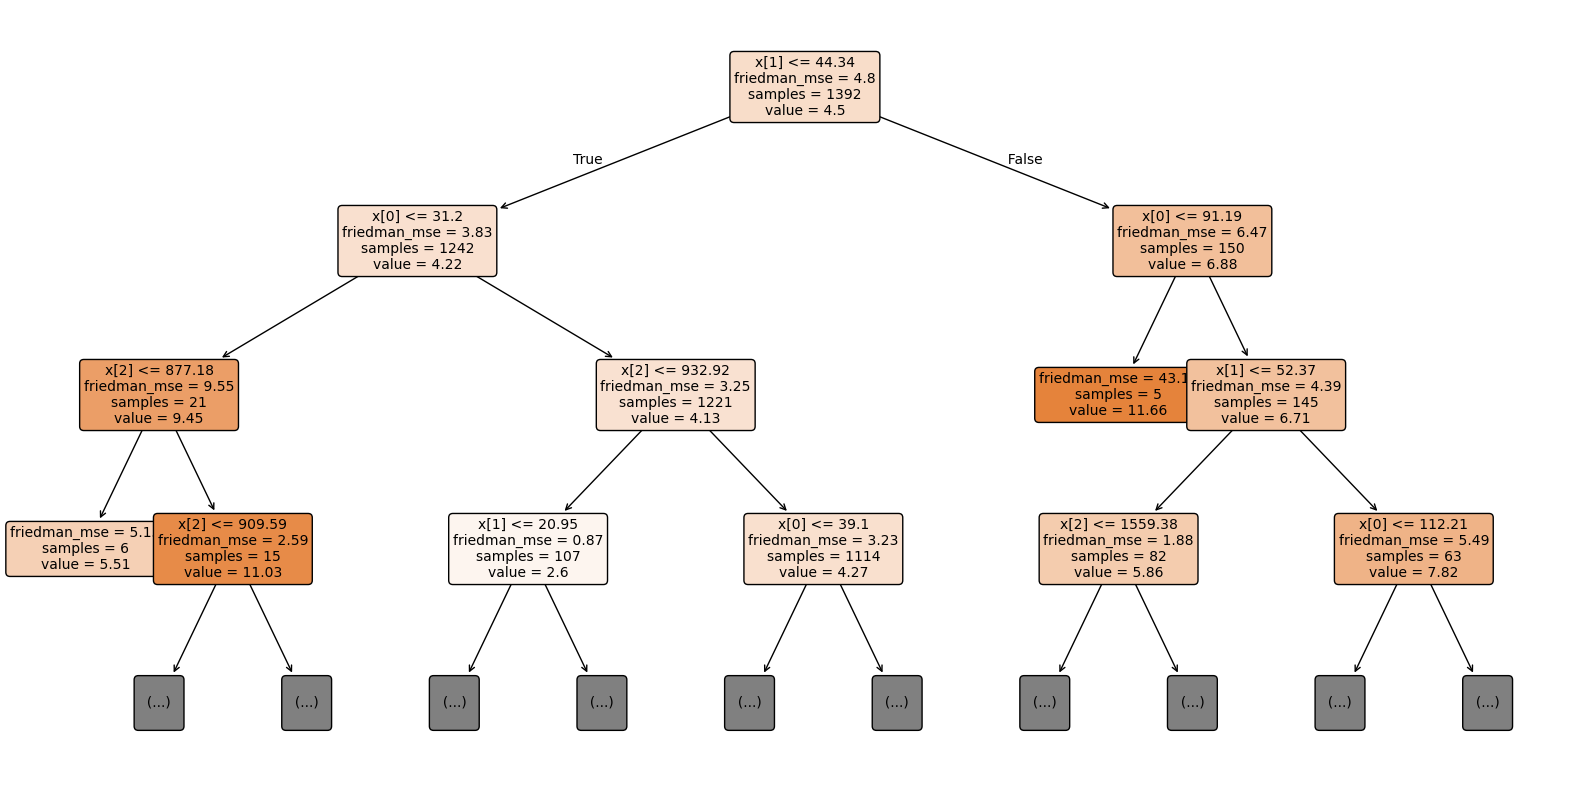

In [82]:
plt.figure(figsize=(20, 10))

plot_tree(
    dt_reg_BMC,
    filled=True,
    rounded=True,
    fontsize=10,
    precision=2,
    max_depth = 3
)

plt.show()

Idx | Actual | Predicted | Error
----------------------------------------
  41 | 22.4353 |   11.7870 | 10.6483
 423 | 15.1353 |    5.3246 | 9.8107
 311 |  2.3325 |    9.4347 | 7.1022
 382 | 17.5715 |   11.7870 | 5.7845
 200 | 16.3969 |   10.8039 | 5.5930
 246 |  0.4167 |    5.6749 | 5.2581
 348 |  9.1154 |    4.8841 | 4.2313
 357 |  7.4504 |   11.6640 | 4.2136
 115 | 11.7784 |    7.5848 | 4.1936
 134 |  0.5630 |    4.7234 | 4.1605


C:\Users\paula\AppData\Local\Temp\ipykernel_13496\1016786874.py:15: UserWarning: No artists with labels found to put in legend.  Note that artists whose label start with an underscore are ignored when legend() is called with no argument.
  plt.legend()


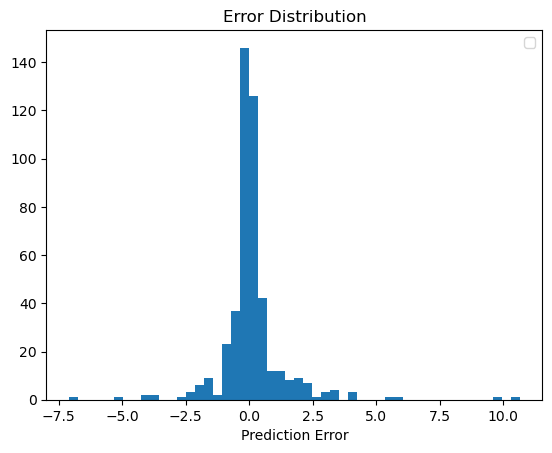

In [83]:
errors = np.abs(y_test - y_pred)

# Top 10 worst predictions
worst_indices = np.argsort(errors)[-10:][::-1]

print("Idx | Actual | Predicted | Error")
print("-" * 40)
for i in worst_indices:
    print(f"{i:4d} | {y_test[i]:7.4f} | {y_pred[i]:9.4f} | {errors[i]:.4f}")

# Error distribution plot
plt.hist(y_test - y_pred, bins=50)
plt.xlabel('Prediction Error')
plt.title('Error Distribution')
plt.legend()
plt.show()

### Feature Importance

In [84]:
zipped = zip(attributes, dt_reg_BMC.feature_importances_)
zipped = sorted(zipped, key=lambda x: x[1], reverse=True)
for col, imp in zipped:
    print(col, imp)

BIA-BIA_LST 0.4693173787807842
BIA-BIA_BMR 0.27681232415121687
BIA-BIA_ICW 0.2538702970679989


## TARGET VARIABLE BIA-BIA_SMM

In [85]:
df_BIA_SMM = df[[
'BIA-BIA_LST',
'BIA-BIA_ICW',
'BIA-BIA_FFM',
'BIA-BIA_SMM'
]]






In [86]:
df_BIA_SMM=df_BIA_SMM.dropna()

In [87]:
df_BIA_SMM.isnull().sum()

BIA-BIA_LST    0
BIA-BIA_ICW    0
BIA-BIA_FFM    0
BIA-BIA_SMM    0
dtype: int64

### Partitioning

In [88]:
attributes = [col for col in df_BIA_SMM.columns if col != 'BIA-BIA_SMM']
X = df_BIA_SMM[attributes].values
y = np.array(df_BIA_SMM['BIA-BIA_SMM'])

In [89]:
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.25, random_state=0)


In [90]:
print(X_train.shape, X_test.shape, y_train.shape, y_test.shape)

(1392, 3) (465, 3) (1392,) (465,)


In [91]:
df_BIA_SMM.shape

(1857, 4)

### Randomized Search

In [92]:
# options for scoring
#scoring='neg_mean_squared_error'      # most common, minimizes large errors
#scoring='neg_mean_absolute_error'     # more robust to outliers
#scoring='neg_root_mean_squared_error' # directly in target units
#scoring='r2'                          # maximizes explained variance

In [93]:
param_list = {
    'max_depth': [None] + list(np.arange(2, 50)),
    'min_samples_split': [0.001, 0.002, 0.01, 0.05, 0.1, 0.2],
    'min_samples_leaf': [5, 10, 20, 30, 50, 100, 150],
    'criterion': ['squared_error', 'absolute_error', 'friedman_mse']  
}

dt_reg_SMM = DecisionTreeRegressor()  

random_search = RandomizedSearchCV(
    DecisionTreeRegressor(),    
    param_distributions=param_list,
    cv=KFold(n_splits=5, shuffle=True, random_state=0), 
    scoring='neg_mean_squared_error' ,   
    n_jobs=-1,
    refit=True,
    n_iter=300,
)

random_search.fit(X_train, y_train)
dt_reg_SMM = random_search.best_estimator_

In [94]:
print(random_search.best_params_, random_search.best_score_)

{'min_samples_split': 0.001, 'min_samples_leaf': 5, 'max_depth': 7, 'criterion': 'friedman_mse'} -18.11566488159589


In [95]:
dt_reg_SMM = random_search.best_estimator_
dt_reg_SMM.fit(X_train, y_train)

DecisionTreeRegressor(criterion='friedman_mse', max_depth=7, min_samples_leaf=5,
                      min_samples_split=0.001)

In [96]:
y_pred = dt_reg_SMM.predict(X_test)

print(f"RMSE : {np.sqrt(mean_squared_error(y_test, y_pred)):.4f}") # Typical error
print(f"MAE  : {mean_absolute_error(y_test, y_pred):.4f}")  #Average Error
print(f"MSE  : {mean_squared_error(y_test, y_pred):.4f}")  #Average Error
print(f"R²   : {r2_score(y_test, y_pred):.4f}") # variance in the target variable

RMSE : 3.7400
MAE  : 2.5096
MSE  : 13.9875
R²   : 0.9191


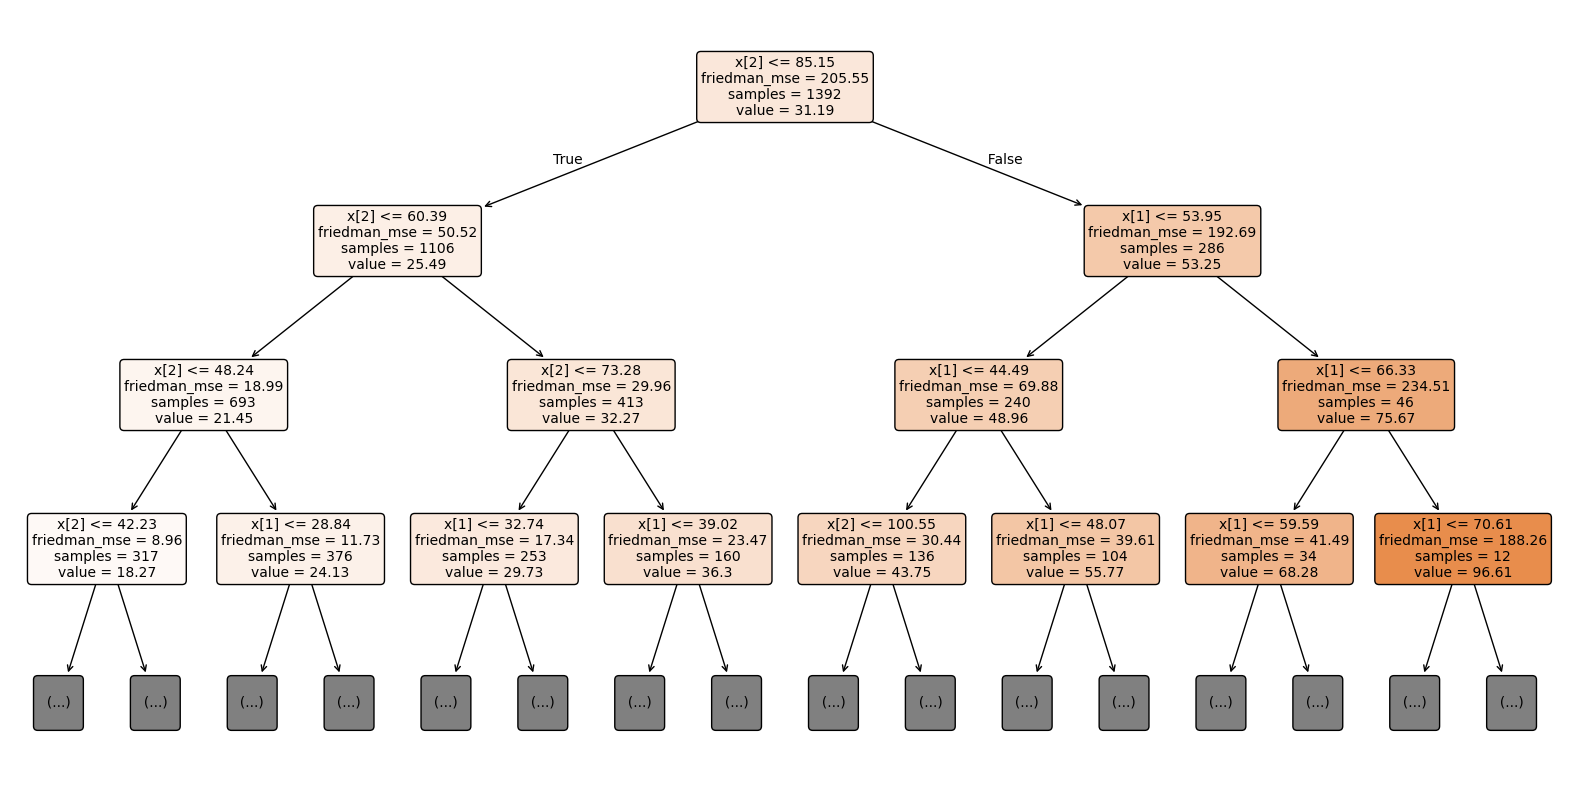

In [97]:
plt.figure(figsize=(20, 10))

plot_tree(
    dt_reg_SMM,
    filled=True,
    rounded=True,
    fontsize=10,
    precision=2,
    max_depth = 3
)

plt.show()

Idx | Actual | Predicted | Error
----------------------------------------
 366 | 87.8876 |  105.5956 | 17.7080
 252 | 89.3602 |   75.1182 | 14.2420
 166 | 50.5667 |   36.4560 | 14.1107
  98 | 44.8130 |   31.2254 | 13.5876
 405 |  4.6557 |   17.4699 | 12.8142
  20 | 44.3983 |   57.1534 | 12.7551
 418 | 34.7367 |   22.7021 | 12.0346
 359 | 44.3498 |   32.3929 | 11.9569
  95 | 46.0271 |   34.3212 | 11.7059
  41 | 32.6623 |   21.6547 | 11.0076


C:\Users\paula\AppData\Local\Temp\ipykernel_13496\1016786874.py:15: UserWarning: No artists with labels found to put in legend.  Note that artists whose label start with an underscore are ignored when legend() is called with no argument.
  plt.legend()


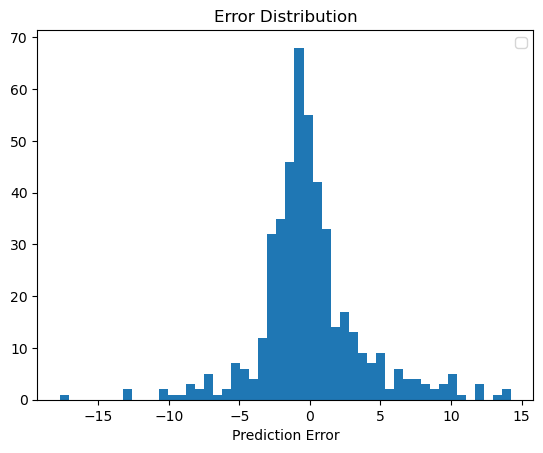

In [98]:
errors = np.abs(y_test - y_pred)

# Top 10 worst predictions
worst_indices = np.argsort(errors)[-10:][::-1]

print("Idx | Actual | Predicted | Error")
print("-" * 40)
for i in worst_indices:
    print(f"{i:4d} | {y_test[i]:7.4f} | {y_pred[i]:9.4f} | {errors[i]:.4f}")

# Error distribution plot
plt.hist(y_test - y_pred, bins=50)
plt.xlabel('Prediction Error')
plt.title('Error Distribution')
plt.legend()
plt.show()

### Feature Importance

In [99]:
zipped = zip(attributes, dt_reg_SMM.feature_importances_)
zipped = sorted(zipped, key=lambda x: x[1], reverse=True)
for col, imp in zipped:
    print(col, imp)

BIA-BIA_FFM 0.8040829917006237
BIA-BIA_ICW 0.19052756869938486
BIA-BIA_LST 0.005389439599991469


## TARGET VARIABLE BIA-BIA_Activity_Level_num

In [268]:
df_BIA_ACT_LEV= df[[
'BIA-BIA_DEE',
'BIA-BIA_FFM',
'BIA-BIA_LST',
'Physical-Weight',
'BIA-BIA_ICW',
'BIA-BIA_TBW',
'BIA-BIA_Activity_Level_num'
]]

In [269]:
df_BIA_ACT_LEV=df_BIA_ACT_LEV.dropna()

In [270]:
df_BIA_ACT_LEV.isnull().sum()

BIA-BIA_DEE                   0
BIA-BIA_FFM                   0
BIA-BIA_LST                   0
Physical-Weight               0
BIA-BIA_ICW                   0
BIA-BIA_TBW                   0
BIA-BIA_Activity_Level_num    0
dtype: int64

### Partitioning

In [271]:
attributes = [col for col in df_BIA_ACT_LEV.columns if col != 'BIA-BIA_Activity_Level_num']
X = df_BIA_ACT_LEV[attributes].values
y = np.array(df_BIA_ACT_LEV['BIA-BIA_Activity_Level_num'])

In [272]:
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.25, random_state=0,stratify=y)


In [273]:
print(np.unique(y, return_counts=True)[1] / len(y))
print(np.unique(y_train, return_counts=True)[1] / len(y_train))
print(np.unique(y_test, return_counts=True)[1] / len(y_test))

[0.13469828 0.32165948 0.35344828 0.1487069  0.04148707]
[0.13433908 0.32183908 0.35344828 0.1487069  0.04166667]
[0.13577586 0.32112069 0.35344828 0.1487069  0.04094828]


In [274]:
print(X_train.shape, X_test.shape, y_train.shape, y_test.shape)

(1392, 6) (464, 6) (1392,) (464,)


In [275]:
df_BIA_ACT_LEV.shape

(1856, 7)

### Randomized Search

In [276]:
param_list = {
    'max_depth': [None] + list(np.arange(2, 20)),
    'min_samples_split': [0.002, 0.01, 0.05, 0.1, 0.2],
    'min_samples_leaf': [5, 10, 20, 30, 50, 100, 150],
    'criterion': ['gini', 'entropy']
}

dt_reg_ACT_LEV = DecisionTreeClassifier(criterion='gini', max_depth=None, min_samples_split=0.002, min_samples_leaf=1)

random_search = RandomizedSearchCV(
    DecisionTreeClassifier(),
    param_distributions=param_list,
    cv=KFold(n_splits=5, shuffle=True, random_state=0),
    n_jobs=-1,
    refit=True,
    n_iter=300,
)

random_search.fit(X_train, y_train)
dt_reg_ACT_LEV = random_search.best_estimator_

In [277]:
print(random_search.best_params_, random_search.best_score_)

{'min_samples_split': 0.002, 'min_samples_leaf': 5, 'max_depth': 18, 'criterion': 'gini'} 0.8419509553647403


In [278]:
dt_reg_ACT_LEV = random_search.best_estimator_
dt_reg_ACT_LEV.fit(X_train, y_train)

DecisionTreeClassifier(max_depth=18, min_samples_leaf=5,
                       min_samples_split=0.002)

In [279]:
y_pred = dt_reg_ACT_LEV.predict(X_test)

print("Accuracy:", accuracy_score(y_test, y_pred))
print(classification_report(y_test, y_pred))

Accuracy: 0.8814655172413793
              precision    recall  f1-score   support

         1.0       0.97      0.98      0.98        63
         2.0       0.86      0.87      0.87       149
         3.0       0.86      0.87      0.87       164
         4.0       0.91      0.88      0.90        69
         5.0       0.81      0.68      0.74        19

    accuracy                           0.88       464
   macro avg       0.88      0.86      0.87       464
weighted avg       0.88      0.88      0.88       464



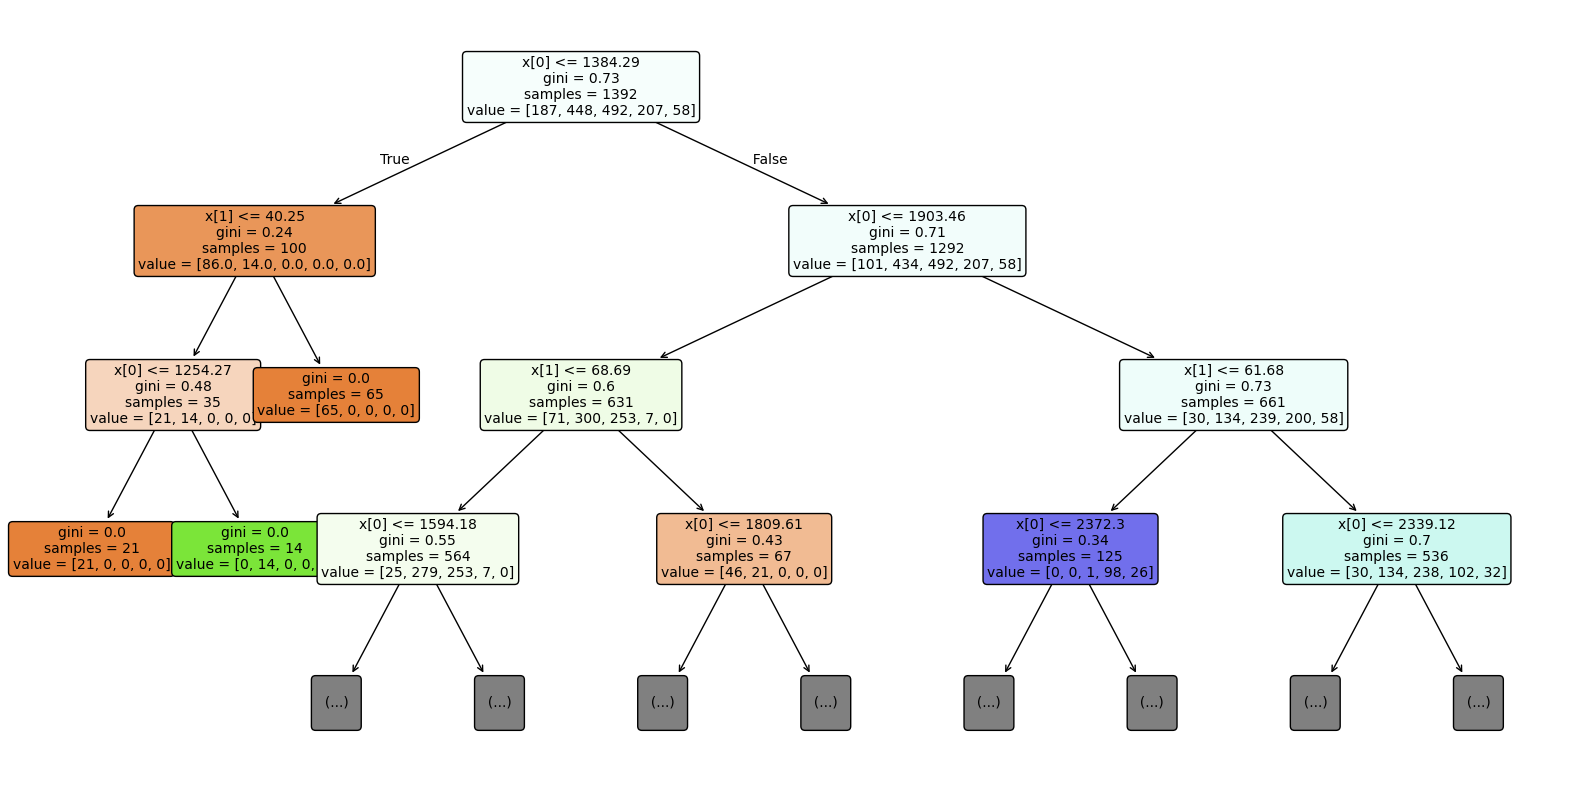

In [280]:
plt.figure(figsize=(20, 10))

plot_tree(
    dt_reg_ACT_LEV,
    filled=True,
    rounded=True,
    fontsize=10,
    precision=2,
    max_depth = 3
)

plt.show()

Idx | Actual | Predicted | Error
----------------------------------------
 439 |  5.0000 |    3.0000 | 2.0000
 463 |  3.0000 |    2.0000 | 1.0000
 178 |  3.0000 |    2.0000 | 1.0000
 384 |  3.0000 |    2.0000 | 1.0000
  60 |  2.0000 |    3.0000 | 1.0000
 267 |  2.0000 |    3.0000 | 1.0000
 389 |  2.0000 |    3.0000 | 1.0000
  51 |  3.0000 |    2.0000 | 1.0000
  50 |  4.0000 |    3.0000 | 1.0000
 402 |  5.0000 |    4.0000 | 1.0000


C:\Users\paula\AppData\Local\Temp\ipykernel_13496\1016786874.py:15: UserWarning: No artists with labels found to put in legend.  Note that artists whose label start with an underscore are ignored when legend() is called with no argument.
  plt.legend()


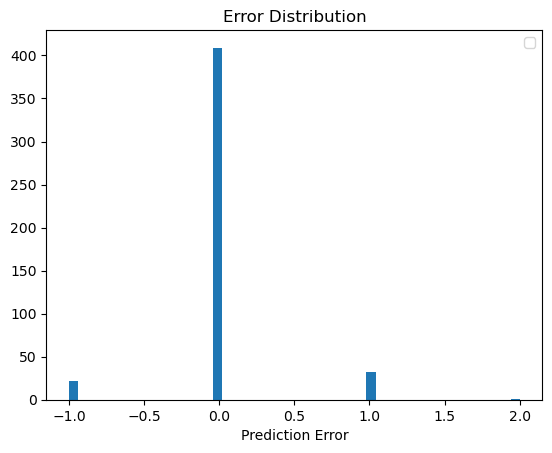

In [281]:
errors = np.abs(y_test - y_pred)

# Top 10 worst predictions
worst_indices = np.argsort(errors)[-10:][::-1]

print("Idx | Actual | Predicted | Error")
print("-" * 40)
for i in worst_indices:
    print(f"{i:4d} | {y_test[i]:7.4f} | {y_pred[i]:9.4f} | {errors[i]:.4f}")

# Error distribution plot
plt.hist(y_test - y_pred, bins=50)
plt.xlabel('Prediction Error')
plt.title('Error Distribution')
plt.legend()
plt.show()

### Feature Importance

In [282]:
zipped = zip(attributes, dt_reg_ACT_LEV.feature_importances_)
zipped = sorted(zipped, key=lambda x: x[1], reverse=True)
for col, imp in zipped:
    print(col, imp)

BIA-BIA_DEE 0.4691518720546304
BIA-BIA_FFM 0.2866139947508846
BIA-BIA_ICW 0.13439315508827926
BIA-BIA_LST 0.05130889997241702
Physical-Weight 0.03789431500504981
BIA-BIA_TBW 0.020637763128738947


## TARGET VARIABLE BIA-BIA_Frame_num

In [115]:
df_BIA_Frame= df[[
       'Physical-Height', 
       'Physical-Weight',
       'BIA-BIA_Fat' ,
       'BIA-BIA_Frame_num'
]]

In [116]:
df_BIA_Frame=df_BIA_Frame.dropna()

In [117]:
df_BIA_Frame.isnull().sum()

Physical-Height      0
Physical-Weight      0
BIA-BIA_Fat          0
BIA-BIA_Frame_num    0
dtype: int64

### Partitioning

In [118]:
attributes = [col for col in df_BIA_Frame.columns if col != 'BIA-BIA_Frame_num']
X = df_BIA_Frame[attributes].values
y = np.array(df_BIA_Frame['BIA-BIA_Frame_num'])

In [119]:
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.25, random_state=0,stratify=y)


In [120]:
print(np.unique(y, return_counts=True)[1] / len(y))
print(np.unique(y_train, return_counts=True)[1] / len(y_train))
print(np.unique(y_test, return_counts=True)[1] / len(y_test))

[0.39385776 0.47306034 0.1330819 ]
[0.39367816 0.47341954 0.1329023 ]
[0.39439655 0.47198276 0.13362069]


In [121]:
print(X_train.shape, X_test.shape, y_train.shape, y_test.shape)

(1392, 3) (464, 3) (1392,) (464,)


In [122]:
df_BIA_Frame.shape

(1856, 4)

### Randomized Search

In [123]:
param_list = {
    'max_depth': [None] + list(np.arange(2, 40)),
    'min_samples_split': [0.002, 0.01, 0.05, 0.1, 0.2],
    'min_samples_leaf': [5, 10, 20, 30, 50, 100, 150],
    'criterion': ['gini', 'entropy']
}

dt_reg_Frame = DecisionTreeClassifier(criterion='gini', max_depth=None, min_samples_split=0.002, min_samples_leaf=1)

random_search = RandomizedSearchCV(
    DecisionTreeClassifier(),
    param_distributions=param_list,
    cv=KFold(n_splits=5, shuffle=True, random_state=0),
    n_jobs=-1,
    refit=True,
    n_iter=300,
)

random_search.fit(X_train, y_train)
dt_reg_Frame = random_search.best_estimator_

In [124]:
print(random_search.best_params_, random_search.best_score_)

{'min_samples_split': 0.05, 'min_samples_leaf': 5, 'max_depth': 3, 'criterion': 'entropy'} 0.6759805059178463


In [125]:
dt_reg_Frame = random_search.best_estimator_
dt_reg_Frame.fit(X_train, y_train)

DecisionTreeClassifier(criterion='entropy', max_depth=3, min_samples_leaf=5,
                       min_samples_split=0.05)

In [126]:
y_pred = dt_reg_Frame.predict(X_test)

print("Accuracy:", accuracy_score(y_test, y_pred))
print(classification_report(y_test, y_pred))

Accuracy: 0.6530172413793104
              precision    recall  f1-score   support

         1.0       0.66      0.68      0.67       183
         2.0       0.63      0.72      0.67       219
         3.0       0.88      0.34      0.49        62

    accuracy                           0.65       464
   macro avg       0.72      0.58      0.61       464
weighted avg       0.67      0.65      0.65       464



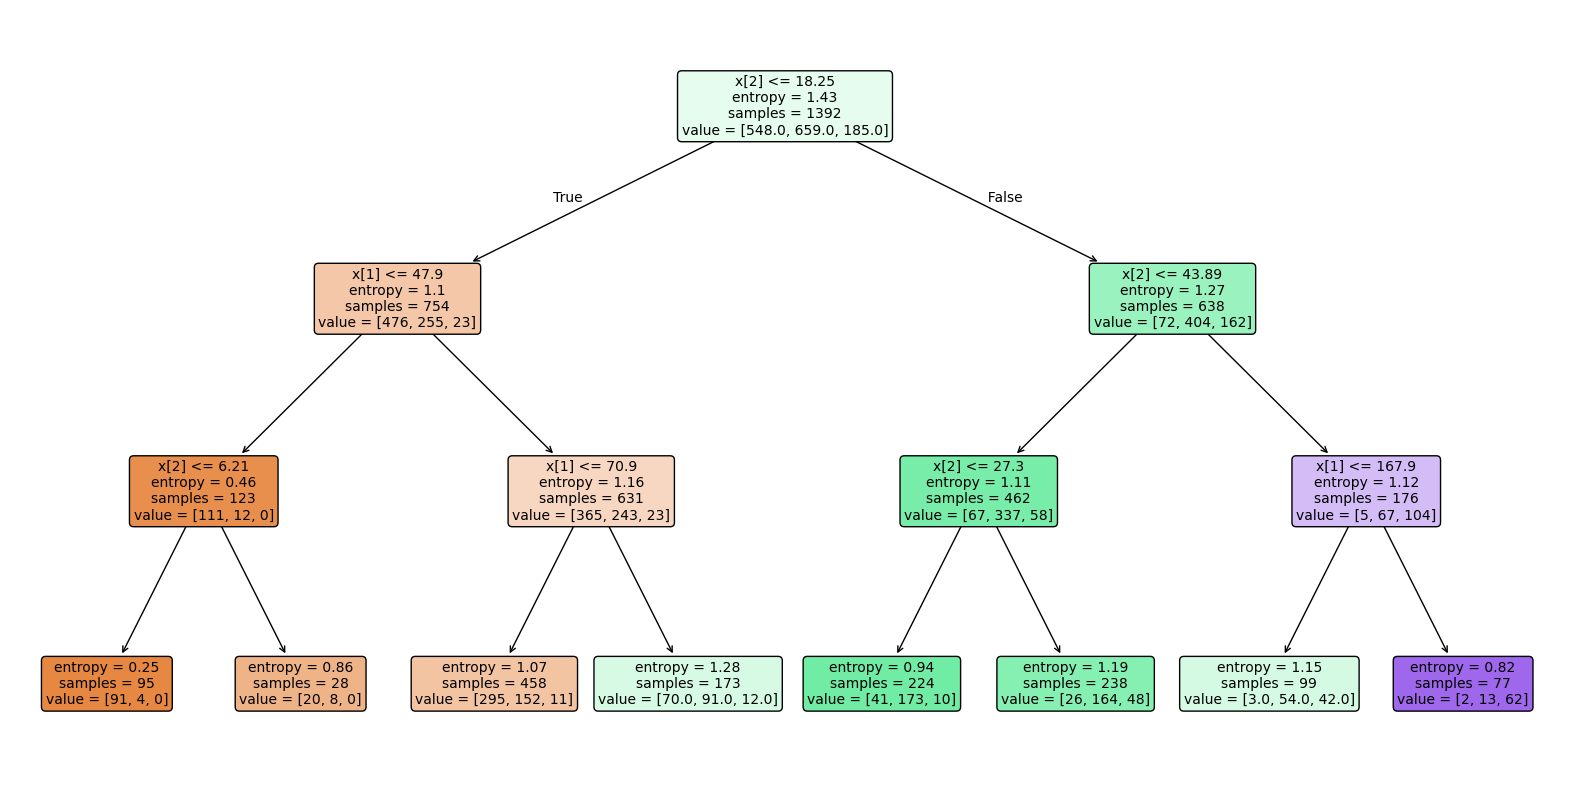

In [127]:
plt.figure(figsize=(20, 10))

plot_tree(
    dt_reg_Frame,
    filled=True,
    rounded=True,
    fontsize=10,
    precision=2,
    max_depth = 3
)

plt.show()

Idx | Actual | Predicted | Error
----------------------------------------
 374 |  3.0000 |    1.0000 | 2.0000
 283 |  3.0000 |    1.0000 | 2.0000
 403 |  3.0000 |    1.0000 | 2.0000
 142 |  3.0000 |    1.0000 | 2.0000
  77 |  3.0000 |    1.0000 | 2.0000
   0 |  1.0000 |    2.0000 | 1.0000
  92 |  2.0000 |    1.0000 | 1.0000
 321 |  1.0000 |    2.0000 | 1.0000
 319 |  1.0000 |    2.0000 | 1.0000
 317 |  1.0000 |    2.0000 | 1.0000


C:\Users\paula\AppData\Local\Temp\ipykernel_13496\1016786874.py:15: UserWarning: No artists with labels found to put in legend.  Note that artists whose label start with an underscore are ignored when legend() is called with no argument.
  plt.legend()


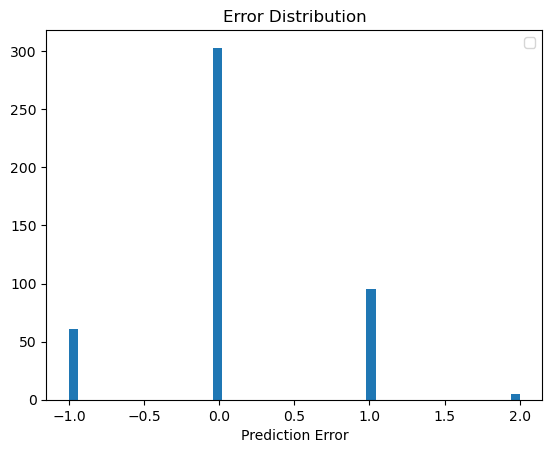

In [128]:
errors = np.abs(y_test - y_pred)

# Top 10 worst predictions
worst_indices = np.argsort(errors)[-10:][::-1]

print("Idx | Actual | Predicted | Error")
print("-" * 40)
for i in worst_indices:
    print(f"{i:4d} | {y_test[i]:7.4f} | {y_pred[i]:9.4f} | {errors[i]:.4f}")

# Error distribution plot
plt.hist(y_test - y_pred, bins=50)
plt.xlabel('Prediction Error')
plt.title('Error Distribution')
plt.legend()
plt.show()

### Feature Importance

In [129]:
zipped = zip(attributes, dt_reg_Frame.feature_importances_)
zipped = sorted(zipped, key=lambda x: x[1], reverse=True)
for col, imp in zipped:
    print(col, imp)

BIA-BIA_Fat 0.8497176180587473
Physical-Weight 0.1502823819412526
Physical-Height 0.0


## ** TARGET VARIABLE Physical-HeartRate

In [130]:
df_HeartRate = df[[
       'Physical-HeartRate', 
       'Physical-Height',
       'Physical-Weight',
       'Physical-MAP_CAL'
       ]].copy()


In [131]:
df_HeartRate=df_HeartRate.dropna()

In [513]:
df_HeartRate.isnull().sum()

Physical-HeartRate    0
Physical-Height       0
Physical-Weight       0
Physical-MAP_CAL      0
dtype: int64

### Partitioning

In [132]:
attributes = [col for col in df_HeartRate.columns if col != 'Physical-HeartRate']
X = df_HeartRate[attributes].values
y = np.array(df_HeartRate['Physical-HeartRate'])

In [133]:
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.25, random_state=0)


In [134]:
print(X_train.shape, X_test.shape, y_train.shape, y_test.shape)

(1389, 3) (464, 3) (1389,) (464,)


In [135]:
df_HeartRate.shape

(1853, 4)

### Randomized Search

In [136]:
# options for scoring
#scoring='neg_mean_squared_error'      # most common, minimizes large errors
#scoring='neg_mean_absolute_error'     # more robust to outliers
#scoring='neg_root_mean_squared_error' # directly in target units
#scoring='r2'                          # maximizes explained variance

In [137]:
param_list = {
    'max_depth': [None] + list(np.arange(2, 50)),
    'min_samples_split': [0.001, 0.002, 0.01, 0.05, 0.1, 0.2],
    'min_samples_leaf': [5, 10, 20, 30, 50, 100, 150],
    'criterion': ['squared_error', 'absolute_error', 'friedman_mse']  
}

dt_reg_HeartRate = DecisionTreeRegressor()  

random_search = RandomizedSearchCV(
    DecisionTreeRegressor(),    
    param_distributions=param_list,
    cv=KFold(n_splits=5, shuffle=True, random_state=0), 
    scoring='neg_mean_squared_error' ,   
    n_jobs=-1,
    refit=True,
    n_iter=300,
)

random_search.fit(X_train, y_train)
dt_reg_HeartRate = random_search.best_estimator_

In [138]:
param_list = {
    'n_estimators': [50, 100, 200, 300, 500],
    'max_depth': [None] + list(np.arange(2, 50)),
    'min_samples_split': [0.001, 0.002, 0.01, 0.05, 0.1, 0.2],
    'min_samples_leaf': [5, 10, 20, 30, 50, 100, 150],
    'criterion': ['squared_error', 'absolute_error', 'friedman_mse'],
    'max_features': ['sqrt', 'log2', None] # Optional: highly recommended to tune for RFs
}

rf_reg_HeartRate = RandomForestRegressor(random_state=0)


random_search = RandomizedSearchCV(
    estimator=RandomForestRegressor(random_state=0),    
    param_distributions=param_list,
    cv=KFold(n_splits=5, shuffle=True, random_state=0), 
    scoring='neg_mean_squared_error',   
    n_jobs=-1,
    refit=True,
    n_iter=300,
    random_state=0 # Ensures the random search picks the same combinations on reruns
)

random_search.fit(X_train, y_train)
dt_reg_HeartRate = random_search.best_estimator_

In [139]:
print(random_search.best_params_, random_search.best_score_)

{'n_estimators': 200, 'min_samples_split': 0.1, 'min_samples_leaf': 30, 'max_features': None, 'max_depth': 48, 'criterion': 'squared_error'} -157.23041192100126


In [140]:
dt_reg_HeartRate = random_search.best_estimator_
dt_reg_HeartRate.fit(X_train, y_train)

RandomForestRegressor(max_depth=48, max_features=None, min_samples_leaf=30,
                      min_samples_split=0.1, n_estimators=200, random_state=0)

In [141]:
y_pred = dt_reg_HeartRate.predict(X_test)

print(f"RMSE : {np.sqrt(mean_squared_error(y_test, y_pred)):.4f}") # Typical error
print(f"MAE  : {mean_absolute_error(y_test, y_pred):.4f}")  #Average Error
print(f"MSE  : {mean_squared_error(y_test, y_pred):.4f}")  #Average Error
print(f"R²   : {r2_score(y_test, y_pred):.4f}") # variance in the target variable

RMSE : 12.7475
MAE  : 10.3858
MSE  : 162.4997
R²   : 0.0176


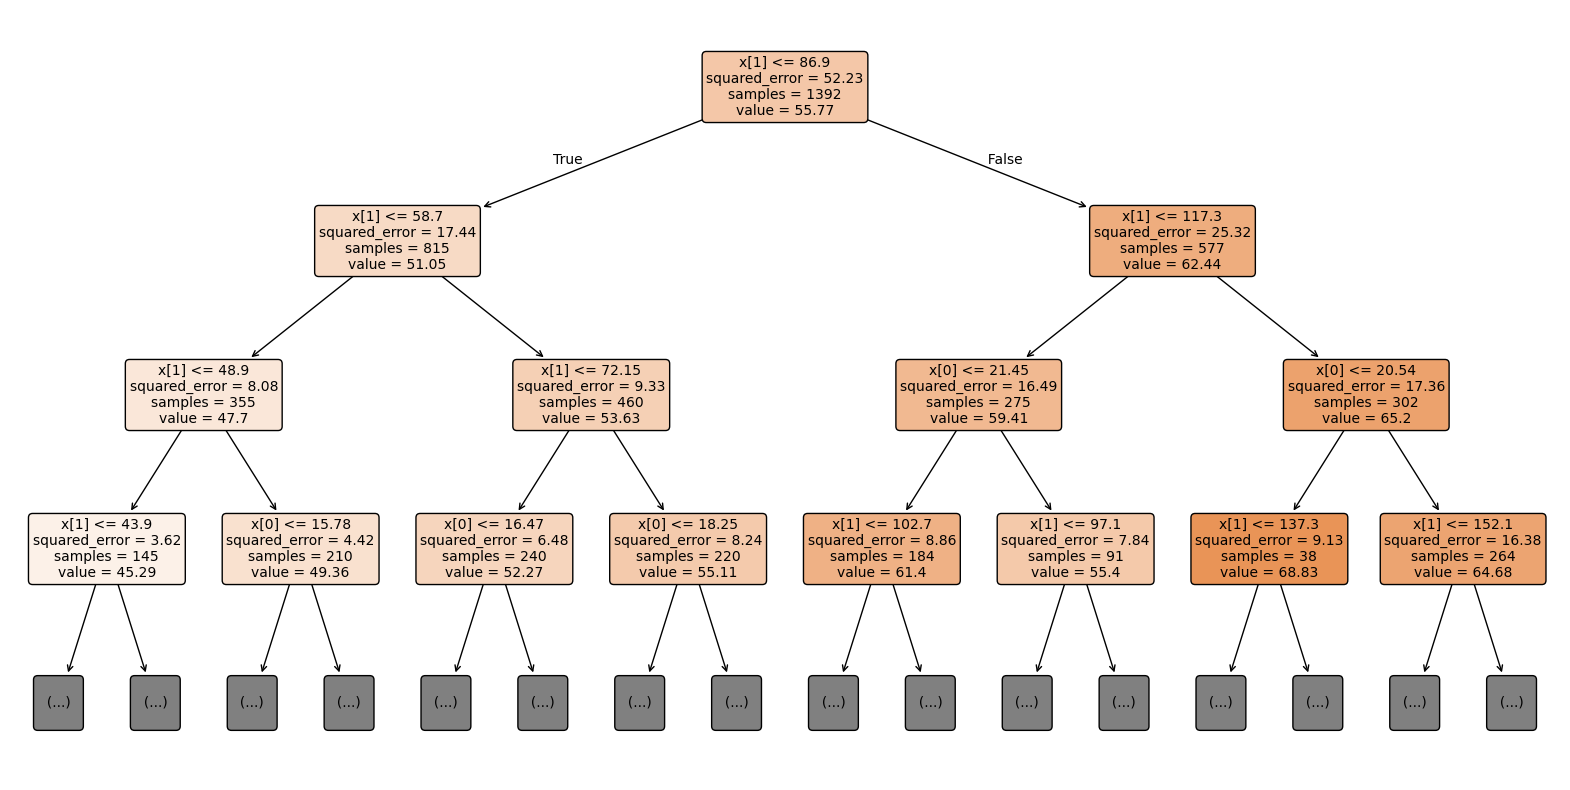

In [142]:
plt.figure(figsize=(20, 10))

plot_tree(
    dt_reg_height,
    filled=True,
    rounded=True,
    fontsize=10,
    precision=2,
    max_depth = 3
)

plt.show()

Idx | Actual | Predicted | Error
----------------------------------------
 358 | 46.0000 |   90.9867 | 44.9867
 443 | 118.0000 |   82.3657 | 35.6343
 109 | 112.0000 |   76.7297 | 35.2703
 296 | 113.0000 |   78.5206 | 34.4794
 151 | 120.0000 |   87.2427 | 32.7573
  72 | 107.0000 |   76.3602 | 30.6398
 240 | 62.0000 |   91.4166 | 29.4166
 348 | 63.0000 |   91.3083 | 28.3083
 123 | 105.0000 |   77.1521 | 27.8479
 219 | 116.0000 |   88.1677 | 27.8323


C:\Users\paula\AppData\Local\Temp\ipykernel_13680\1016786874.py:15: UserWarning: No artists with labels found to put in legend.  Note that artists whose label start with an underscore are ignored when legend() is called with no argument.
  plt.legend()


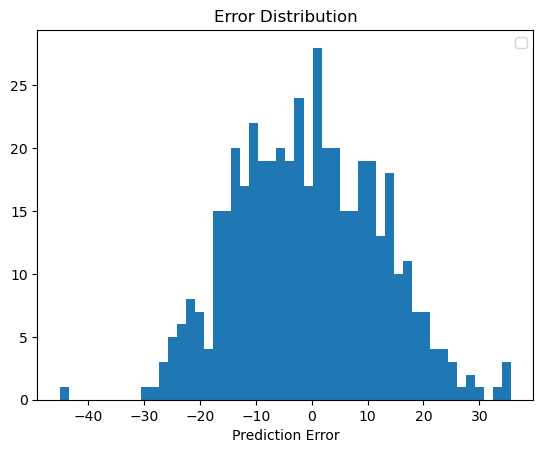

In [143]:
errors = np.abs(y_test - y_pred)

# Top 10 worst predictions
worst_indices = np.argsort(errors)[-10:][::-1]

print("Idx | Actual | Predicted | Error")
print("-" * 40)
for i in worst_indices:
    print(f"{i:4d} | {y_test[i]:7.4f} | {y_pred[i]:9.4f} | {errors[i]:.4f}")

# Error distribution plot
plt.hist(y_test - y_pred, bins=50)
plt.xlabel('Prediction Error')
plt.title('Error Distribution')
plt.legend()
plt.show()

### Feature Importance

In [525]:
zipped = zip(attributes, dt_reg_HeartRate.feature_importances_)
zipped = sorted(zipped, key=lambda x: x[1], reverse=True)
for col, imp in zipped:
    print(col, imp)

Physical-Height 0.5092667203867849
Physical-MAP_CAL 0.4907332796132152
Physical-Weight 0.0


## ** TARGET VARIABLE CGAS-CGAS_Score'

In [577]:
df_CGAS_Score = df[[
'CGAS-CGAS_Score', 
'SDS-SDS_Total_T',
'Physical-BMI',
'FGC-FGC_CORE_CAL',
'Physical-Weight'      
       ]].copy()



In [578]:
df_CGAS_Score=df_CGAS_Score.dropna()

In [579]:
df_CGAS_Score.isnull().sum()

CGAS-CGAS_Score     0
SDS-SDS_Total_T     0
Physical-BMI        0
FGC-FGC_CORE_CAL    0
Physical-Weight     0
dtype: int64

### Partitioning

In [580]:
attributes = [col for col in df_CGAS_Score.columns if col != 'CGAS-CGAS_Score']
X = df_CGAS_Score[attributes].values
y = np.array(df_CGAS_Score['CGAS-CGAS_Score'])

In [581]:
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.25, random_state=0)


In [582]:
print(X_train.shape, X_test.shape, y_train.shape, y_test.shape)

(1114, 4) (372, 4) (1114,) (372,)


In [583]:
df_CGAS_Score.shape

(1486, 5)

### Randomized Search

In [533]:
# options for scoring
#scoring='neg_mean_squared_error'      # most common, minimizes large errors
#scoring='neg_mean_absolute_error'     # more robust to outliers
#scoring='neg_root_mean_squared_error' # directly in target units
#scoring='r2'                          # maximizes explained variance

In [534]:
param_list = {
    'max_depth': [None] + list(np.arange(2, 50)),
    'min_samples_split': [0.001, 0.002, 0.01, 0.05, 0.1, 0.2],
    'min_samples_leaf': [5, 10, 20, 30, 50, 100, 150],
    'criterion': ['squared_error', 'absolute_error', 'friedman_mse']  
}

dt_reg_CGAS_Score = DecisionTreeRegressor()  

random_search = RandomizedSearchCV(
    DecisionTreeRegressor(),    
    param_distributions=param_list,
    cv=KFold(n_splits=5, shuffle=True, random_state=0), 
    scoring='neg_mean_squared_error' ,   
    n_jobs=-1,
    refit=True,
    n_iter=300,
)

random_search.fit(X_train, y_train)
dt_reg_CGAS_Score = random_search.best_estimator_

In [584]:
param_list = {
    'n_estimators': [50, 100, 200, 300, 500],
    'max_depth': [None] + list(np.arange(2, 50)),
    'min_samples_split': [0.001, 0.002, 0.01, 0.05, 0.1, 0.2],
    'min_samples_leaf': [5, 10, 20, 30, 50, 100, 150],
    'criterion': ['squared_error', 'absolute_error', 'friedman_mse'],
    'max_features': ['sqrt', 'log2', None] # Optional: highly recommended to tune for RFs
}

dt_reg_CGAS_Score = RandomForestRegressor(random_state=0)


random_search = RandomizedSearchCV(
    estimator=RandomForestRegressor(random_state=0),    
    param_distributions=param_list,
    cv=KFold(n_splits=5, shuffle=True, random_state=0), 
    scoring='neg_mean_squared_error',   
    n_jobs=-1,
    refit=True,
    n_iter=300,
    random_state=0 # Ensures the random search picks the same combinations on reruns
)

random_search.fit(X_train, y_train)
dt_reg_CGAS_Score = random_search.best_estimator_

In [585]:
print(random_search.best_params_, random_search.best_score_)

{'n_estimators': 50, 'min_samples_split': 0.001, 'min_samples_leaf': 20, 'max_features': None, 'max_depth': 3, 'criterion': 'squared_error'} -121.08586900937891


In [586]:
dt_reg_CGAS_Score = random_search.best_estimator_
dt_reg_CGAS_Score.fit(X_train, y_train)

RandomForestRegressor(max_depth=3, max_features=None, min_samples_leaf=20,
                      min_samples_split=0.001, n_estimators=50, random_state=0)

In [587]:
y_pred = dt_reg_CGAS_Score.predict(X_test)

print(f"RMSE : {np.sqrt(mean_squared_error(y_test, y_pred)):.4f}") # Typical error
print(f"MAE  : {mean_absolute_error(y_test, y_pred):.4f}")  #Average Error
print(f"MSE  : {mean_squared_error(y_test, y_pred):.4f}")  #Average Error
print(f"R²   : {r2_score(y_test, y_pred):.4f}") # variance in the target variable

RMSE : 11.0508
MAE  : 8.9680
MSE  : 122.1200
R²   : 0.0221


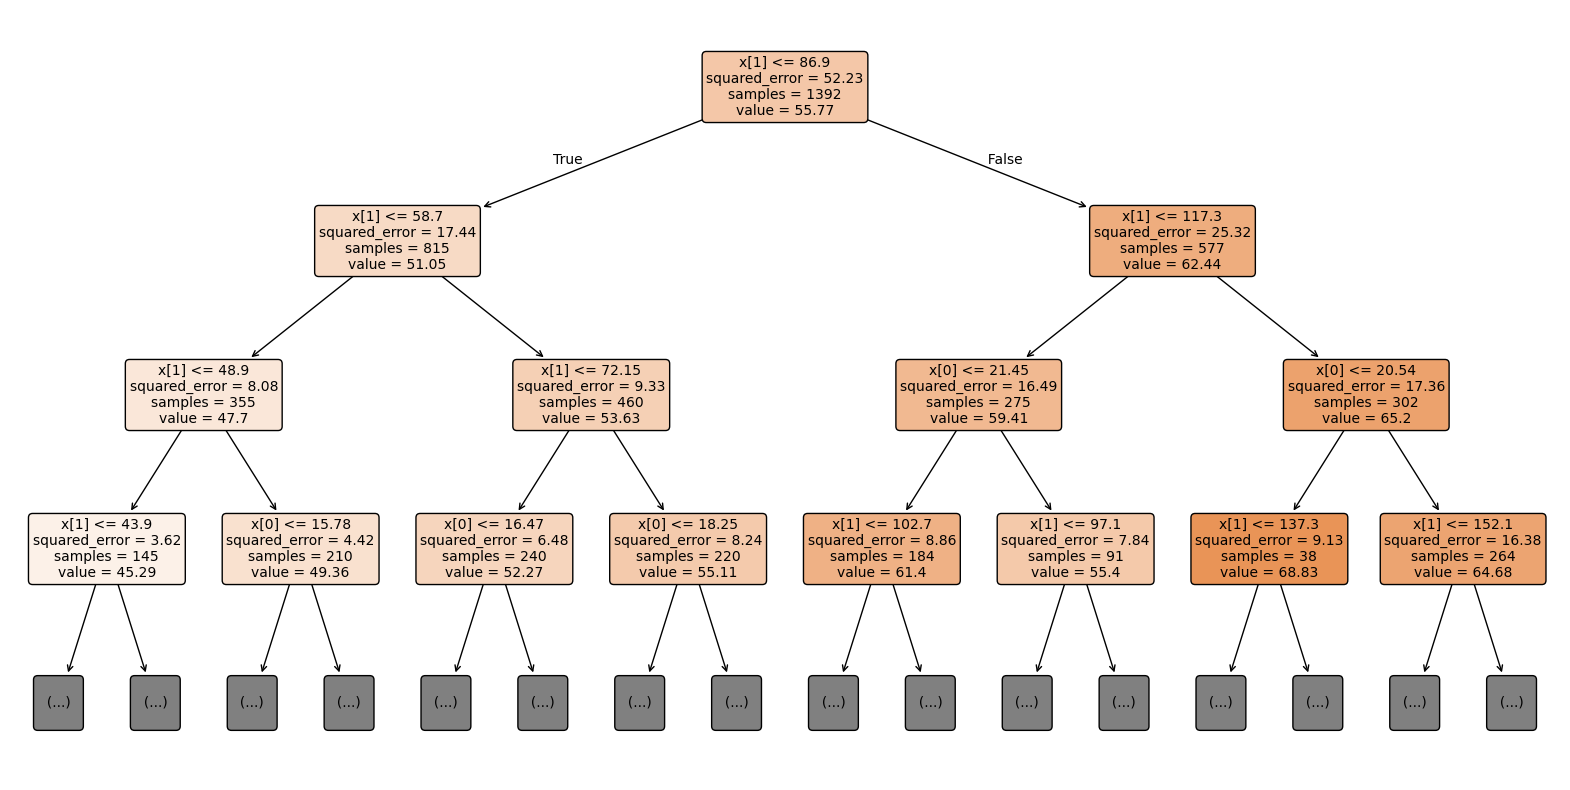

In [538]:
plt.figure(figsize=(20, 10))

plot_tree(
    dt_reg_height,
    filled=True,
    rounded=True,
    fontsize=10,
    precision=2,
    max_depth = 3
)

plt.show()

Idx | Actual | Predicted | Error
----------------------------------------
  98 | 39.0000 |   69.9022 | 30.9022
 345 | 40.0000 |   67.8304 | 27.8304
 162 | 41.0000 |   67.2373 | 26.2373
 117 | 41.0000 |   67.2373 | 26.2373
 301 | 90.0000 |   64.0580 | 25.9420
 125 | 45.0000 |   69.9022 | 24.9022
 250 | 92.0000 |   67.8304 | 24.1696
 220 | 91.0000 |   67.8304 | 23.1696
 160 | 45.0000 |   67.8304 | 22.8304
 154 | 45.0000 |   67.8304 | 22.8304


C:\Users\paula\AppData\Local\Temp\ipykernel_11568\1016786874.py:15: UserWarning: No artists with labels found to put in legend.  Note that artists whose label start with an underscore are ignored when legend() is called with no argument.
  plt.legend()


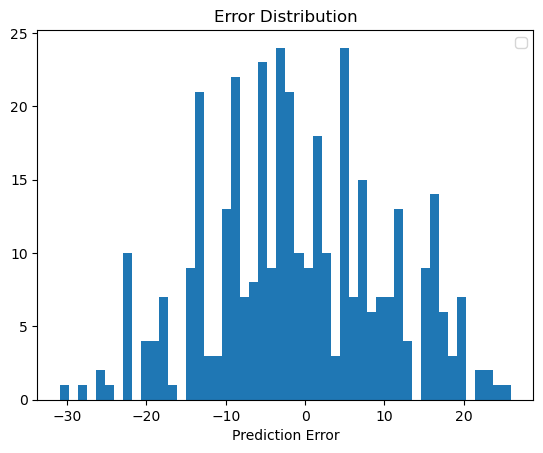

In [539]:
errors = np.abs(y_test - y_pred)

# Top 10 worst predictions
worst_indices = np.argsort(errors)[-10:][::-1]

print("Idx | Actual | Predicted | Error")
print("-" * 40)
for i in worst_indices:
    print(f"{i:4d} | {y_test[i]:7.4f} | {y_pred[i]:9.4f} | {errors[i]:.4f}")

# Error distribution plot
plt.hist(y_test - y_pred, bins=50)
plt.xlabel('Prediction Error')
plt.title('Error Distribution')
plt.legend()
plt.show()

### Feature Importance

In [540]:
zipped = zip(attributes, dt_reg_CGAS_Score.feature_importances_)
zipped = sorted(zipped, key=lambda x: x[1], reverse=True)
for col, imp in zipped:
    print(col, imp)

SDS-SDS_Total_T 0.390062618848251
FGC-FGC_CORE_CAL 0.37908151418651403
Physical-Weight 0.16720230421270094
Physical-BMI 0.06365356275253412


## ** TARGET VARIABLE Fitness_Endurance-Max_Stage

In [598]:
df_Fitness_Endurance= df[[
'Physical-Weight',
'FGC-FGC_CORE_CAL',
'Basic_Demos-Age',
'Basic_Demos-Sex', 
'Physical-Height',
'BIA-BIA_FMI',
'Physical-MAP_CAL',
'BIA-BIA_TBW',
'Fitness_Endurance-Max_Stage'
]]



In [599]:
df_Fitness_Endurance=df_Fitness_Endurance.dropna()

In [600]:
df_Fitness_Endurance.isnull().sum()

Physical-Weight                0
FGC-FGC_CORE_CAL               0
Basic_Demos-Age                0
Basic_Demos-Sex                0
Physical-Height                0
BIA-BIA_FMI                    0
Physical-MAP_CAL               0
BIA-BIA_TBW                    0
Fitness_Endurance-Max_Stage    0
dtype: int64

### Partitioning

In [601]:
attributes = [col for col in df_Fitness_Endurance.columns if col != 'Fitness_Endurance-Max_Stage']
X = df_Fitness_Endurance[attributes].values
y = np.array(df_Fitness_Endurance['Fitness_Endurance-Max_Stage'])

In [602]:
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.25, random_state=0)


In [603]:
print(X_train.shape, X_test.shape, y_train.shape, y_test.shape)

(904, 8) (302, 8) (904,) (302,)


In [604]:
df_Fitness_Endurance.shape

(1206, 9)

### Randomized Search

In [563]:
param_list = {
    'max_depth': [None] + list(np.arange(2, 20)),
    'min_samples_split': [0.002, 0.01, 0.05, 0.1, 0.2],
    'min_samples_leaf': [5, 10, 20, 30, 50, 100, 150],
    'criterion': ['gini', 'entropy']
}

dt_reg_Fitness_Endurance = DecisionTreeClassifier(criterion='gini', max_depth=None, min_samples_split=0.002, min_samples_leaf=1)

random_search = RandomizedSearchCV(
    DecisionTreeClassifier(),
    param_distributions=param_list,
    cv=KFold(n_splits=5, shuffle=True, random_state=0),
    n_jobs=-1,
    refit=True,
    n_iter=300,
)

random_search.fit(X_train, y_train)
dt_reg_Fitness_Endurance = random_search.best_estimator_

In [605]:
param_list = {
    'n_estimators': [50, 100, 200, 300, 500],
    'max_depth': [None] + list(np.arange(2, 50)),
    'min_samples_split': [0.001, 0.002, 0.01, 0.05, 0.1, 0.2],
    'min_samples_leaf': [5, 10, 20, 30, 50, 100, 150],
    'criterion': ['squared_error', 'absolute_error', 'friedman_mse'],
    'max_features': ['sqrt', 'log2', None] # Optional: highly recommended to tune for RFs
}

dt_reg_Fitness_Endurance = RandomForestRegressor(random_state=0)


random_search = RandomizedSearchCV(
    estimator=RandomForestRegressor(random_state=0),    
    param_distributions=param_list,
    cv=KFold(n_splits=5, shuffle=True, random_state=0), 
    scoring='neg_mean_squared_error',   
    n_jobs=-1,
    refit=True,
    n_iter=300,
    random_state=0 # Ensures the random search picks the same combinations on reruns
)

random_search.fit(X_train, y_train)
dt_reg_Fitness_Endurance = random_search.best_estimator_

In [611]:
param_list = {
    'n_estimators': [50, 100, 200, 300, 500],
    'max_depth': [None] + list(np.arange(2, 20)),
    'min_samples_split': [0.002, 0.01, 0.05, 0.1, 0.2],
    'min_samples_leaf': [5, 10, 20, 30, 50, 100, 150],
    'criterion': ['gini', 'entropy']
}

dt_reg_Fitness_Endurance = RandomForestClassifier(random_state=0)

random_search = RandomizedSearchCV(
    estimator=RandomForestClassifier(random_state=0), # Added random_state for reproducibility
    param_distributions=param_list,
    cv=KFold(n_splits=5, shuffle=True, random_state=0),
    n_jobs=-1,
    refit=True,
    n_iter=300,
    random_state=0 # Good practice for RandomizedSearchCV
)

random_search.fit(X_train, y_train)
dt_reg_Fitness_Endurance = random_search.best_estimator_

In [612]:
print(random_search.best_params_, random_search.best_score_)

{'n_estimators': 100, 'min_samples_split': 0.002, 'min_samples_leaf': 5, 'max_depth': 19, 'criterion': 'gini'} 0.6836279926335175


In [613]:
dt_reg_Fitness_Endurance = random_search.best_estimator_
dt_reg_Fitness_Endurance.fit(X_train, y_train)

RandomForestClassifier(max_depth=19, min_samples_leaf=5,
                       min_samples_split=0.002, random_state=0)

In [614]:
y_pred = dt_reg_Fitness_Endurance.predict(X_test)

print("Accuracy:", accuracy_score(y_test, y_pred))
print(classification_report(y_test, y_pred))

Accuracy: 0.6589403973509934
              precision    recall  f1-score   support

         1.0       0.00      0.00      0.00         4
         2.0       0.00      0.00      0.00        10
         3.0       0.00      0.00      0.00        16
         4.0       0.00      0.00      0.00        21
         5.0       0.67      0.99      0.80       196
         6.0       0.44      0.12      0.20        32
         7.0       0.00      0.00      0.00        20
         8.0       0.00      0.00      0.00         1
        11.0       0.00      0.00      0.00         1
        12.0       0.00      0.00      0.00         1

    accuracy                           0.66       302
   macro avg       0.11      0.11      0.10       302
weighted avg       0.48      0.66      0.54       302



c:\Users\paula\anaconda3\Lib\site-packages\sklearn\metrics\_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
c:\Users\paula\anaconda3\Lib\site-packages\sklearn\metrics\_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
c:\Users\paula\anaconda3\Lib\site-packages\sklearn\metrics\_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))


In [609]:
y_pred = dt_reg_Fitness_Endurance.predict(X_test)

print(f"RMSE : {np.sqrt(mean_squared_error(y_test, y_pred)):.4f}") # Typical error
print(f"MAE  : {mean_absolute_error(y_test, y_pred):.4f}")  #Average Error
print(f"MSE  : {mean_squared_error(y_test, y_pred):.4f}")  #Average Error
print(f"R²   : {r2_score(y_test, y_pred):.4f}") # variance in the target variable

RMSE : 1.1639
MAE  : 0.6911
MSE  : 1.3546
R²   : 0.0798


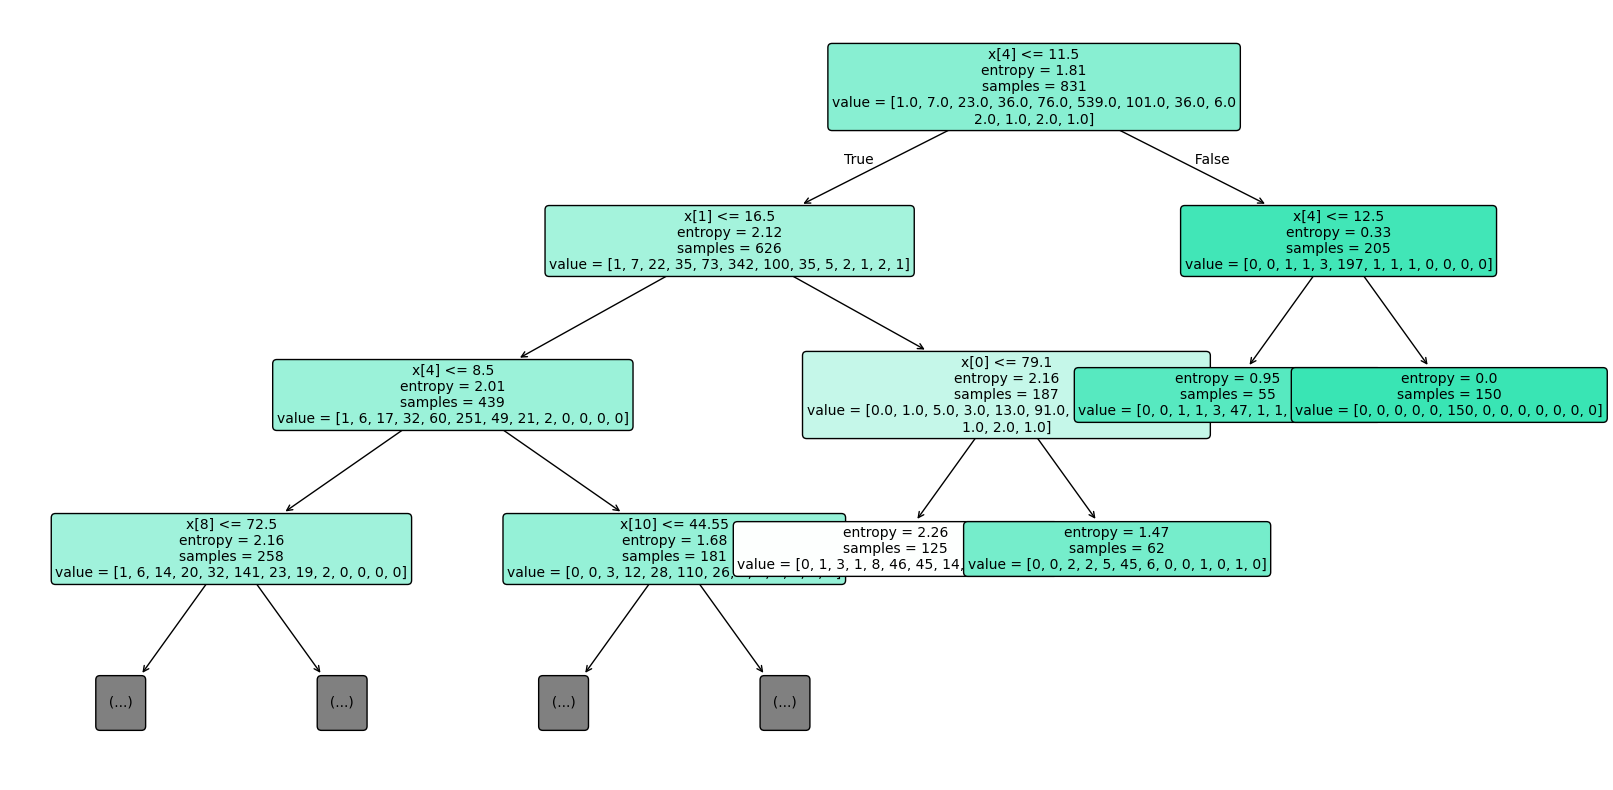

In [567]:
plt.figure(figsize=(20, 10))

plot_tree(
    dt_reg_Fitness_Endurance,
    filled=True,
    rounded=True,
    fontsize=10,
    precision=2,
    max_depth = 3
)

plt.show()

Idx | Actual | Predicted | Error
----------------------------------------
  18 | 26.0000 |    5.0000 | 21.0000
 109 |  1.0000 |    5.0000 | 4.0000
  86 |  1.0000 |    5.0000 | 4.0000
 254 |  9.0000 |    5.0000 | 4.0000
  66 |  9.0000 |    5.0000 | 4.0000
 174 |  1.0000 |    5.0000 | 4.0000
 119 |  2.0000 |    5.0000 | 3.0000
  81 |  8.0000 |    5.0000 | 3.0000
 230 |  2.0000 |    5.0000 | 3.0000
 168 |  2.0000 |    5.0000 | 3.0000


C:\Users\paula\AppData\Local\Temp\ipykernel_11568\1016786874.py:15: UserWarning: No artists with labels found to put in legend.  Note that artists whose label start with an underscore are ignored when legend() is called with no argument.
  plt.legend()


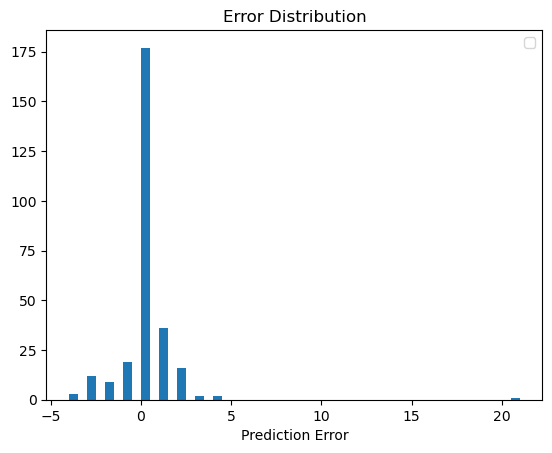

In [568]:
errors = np.abs(y_test - y_pred)

# Top 10 worst predictions
worst_indices = np.argsort(errors)[-10:][::-1]

print("Idx | Actual | Predicted | Error")
print("-" * 40)
for i in worst_indices:
    print(f"{i:4d} | {y_test[i]:7.4f} | {y_pred[i]:9.4f} | {errors[i]:.4f}")

# Error distribution plot
plt.hist(y_test - y_pred, bins=50)
plt.xlabel('Prediction Error')
plt.title('Error Distribution')
plt.legend()
plt.show()

### Feature Importance

In [569]:
zipped = zip(attributes, dt_reg_Fitness_Endurance.feature_importances_)
zipped = sorted(zipped, key=lambda x: x[1], reverse=True)
for col, imp in zipped:
    print(col, imp)

Basic_Demos-Age 0.5424996275112838
FGC-FGC_CORE_CAL 0.15101097301599659
Physical-Weight 0.10970221586720268
BIA-BIA_FMI 0.07828371173741437
Physical-MAP_CAL 0.07247031681005306
BIA-BIA_TBW 0.04603315505804928
CGAS-CGAS_Score 0.0
BIA-BIA_FFMI 0.0
Basic_Demos-Sex 0.0
Physical-Height 0.0
Physical-HeartRate 0.0


## ** TARGET VARIABLE FGC-FGC_TL

In [661]:
df_FGC_TL= df[[
'FGC-FGC_TL',
'FGC-FGC_CORE_CAL',
'FGC-FGC_SR_CAL',
'BIA-BIA_ECW',
'Basic_Demos-Age',
'Basic_Demos-Sex',
'Physical-Weight',
'Physical-Height',
'BIA-BIA_TBW'
]]





In [635]:
df_FGC_TL=df_FGC_TL.dropna()

In [636]:
df_FGC_TL.isnull().sum()

FGC-FGC_TL          0
FGC-FGC_CORE_CAL    0
FGC-FGC_SR_CAL      0
BIA-BIA_ECW         0
Basic_Demos-Age     0
Basic_Demos-Sex     0
Physical-Weight     0
Physical-Height     0
BIA-BIA_TBW         0
dtype: int64

### Partitioning

In [637]:
attributes = [col for col in df_FGC_TL.columns if col != 'FGC-FGC_TL']
X = df_FGC_TL[attributes].values
y = np.array(df_FGC_TL['FGC-FGC_TL'])

In [638]:
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.25, random_state=0)


In [639]:
print(X_train.shape, X_test.shape, y_train.shape, y_test.shape)

(1281, 8) (427, 8) (1281,) (427,)


In [640]:
df_FGC_TL.shape

(1708, 9)

### Randomized Search

In [299]:
# options for scoring
#scoring='neg_mean_squared_error'      # most common, minimizes large errors
#scoring='neg_mean_absolute_error'     # more robust to outliers
#scoring='neg_root_mean_squared_error' # directly in target units
#scoring='r2'                          # maximizes explained variance

In [ ]:
param_list = {
    'max_depth': [None] + list(np.arange(2, 50)),
    'min_samples_split': [0.001, 0.002, 0.01, 0.05, 0.1, 0.2],
    'min_samples_leaf': [5, 10, 20, 30, 50, 100, 150],
    'criterion': ['squared_error', 'absolute_error', 'friedman_mse']  
}

dt_reg_FGC_TL = DecisionTreeRegressor()  

random_search = RandomizedSearchCV(
    DecisionTreeRegressor(),    
    param_distributions=param_list,
    cv=KFold(n_splits=10, shuffle=True, random_state=0), 
    scoring='neg_mean_squared_error' ,   
    n_jobs=-1,
    refit=True,
    n_iter=300,
)

random_search.fit(X_train, y_train)
dt_reg_FGC_TL = random_search.best_estimator_

In [641]:
param_list = {
    'n_estimators': [50, 100, 200, 300, 500],
    'max_depth': [None] + list(np.arange(2, 50)),
    'min_samples_split': [0.001, 0.002, 0.01, 0.05, 0.1, 0.2],
    'min_samples_leaf': [5, 10, 20, 30, 50, 100, 150],
    'criterion': ['squared_error', 'absolute_error', 'friedman_mse'],
    'max_features': ['sqrt', 'log2', None] # Optional: highly recommended to tune for RFs
}

dt_reg_FGC_TL = RandomForestRegressor(random_state=0)


random_search = RandomizedSearchCV(
    estimator=RandomForestRegressor(random_state=0),    
    param_distributions=param_list,
    cv=KFold(n_splits=5, shuffle=True, random_state=0), 
    scoring='neg_mean_squared_error',   
    n_jobs=-1,
    refit=True,
    n_iter=300,
    random_state=0 # Ensures the random search picks the same combinations on reruns
)

random_search.fit(X_train, y_train)
dt_reg_FGC_TL = random_search.best_estimator_

In [642]:
print(random_search.best_params_, random_search.best_score_)

{'n_estimators': 300, 'min_samples_split': 0.002, 'min_samples_leaf': 50, 'max_features': None, 'max_depth': 26, 'criterion': 'squared_error'} -6.545055488999864


In [643]:
dt_reg_FGC_TL = random_search.best_estimator_
dt_reg_FGC_TL.fit(X_train, y_train)

RandomForestRegressor(max_depth=26, max_features=None, min_samples_leaf=50,
                      min_samples_split=0.002, n_estimators=300,
                      random_state=0)

In [644]:
y_pred = dt_reg_FGC_TL.predict(X_test)

print(f"RMSE : {np.sqrt(mean_squared_error(y_test, y_pred)):.4f}") # Typical error
print(f"MAE  : {mean_absolute_error(y_test, y_pred):.4f}")  #Average Error
print(f"MSE  : {mean_squared_error(y_test, y_pred):.4f}")  #Average Error
print(f"R²   : {r2_score(y_test, y_pred):.4f}") # variance in the target variable

RMSE : 2.6028
MAE  : 2.0655
MSE  : 6.7744
R²   : 0.1675


In [645]:
plt.figure(figsize=(20, 10))

plot_tree(
    dt_reg_FGC_TL,
    filled=True,
    rounded=True,
    fontsize=10,
    precision=2,
    max_depth = 3
)

plt.show()

InvalidParameterError: The 'decision_tree' parameter of plot_tree must be an instance of 'sklearn.tree._classes.DecisionTreeClassifier' or an instance of 'sklearn.tree._classes.DecisionTreeRegressor'. Got RandomForestRegressor(max_depth=26, max_features=None, min_samples_leaf=50,
                      min_samples_split=0.002, n_estimators=300,
                      random_state=0) instead.

<Figure size 2000x1000 with 0 Axes>

Idx | Actual | Predicted | Error
----------------------------------------
  43 |  0.0000 |    9.1081 | 9.1081
  38 | 19.0000 |    9.9770 | 9.0230
 296 |  0.0000 |    8.0600 | 8.0600
 242 |  3.0000 |   10.3868 | 7.3868
 384 |  0.0000 |    6.8710 | 6.8710
  61 | 15.0000 |    8.4781 | 6.5219
   4 | 17.0000 |   10.8748 | 6.1252
  11 |  5.0000 |   11.0936 | 6.0936
 349 |  3.0000 |    9.0070 | 6.0070
 115 |  2.0000 |    7.9957 | 5.9957


C:\Users\paula\AppData\Local\Temp\ipykernel_11568\1016786874.py:15: UserWarning: No artists with labels found to put in legend.  Note that artists whose label start with an underscore are ignored when legend() is called with no argument.
  plt.legend()


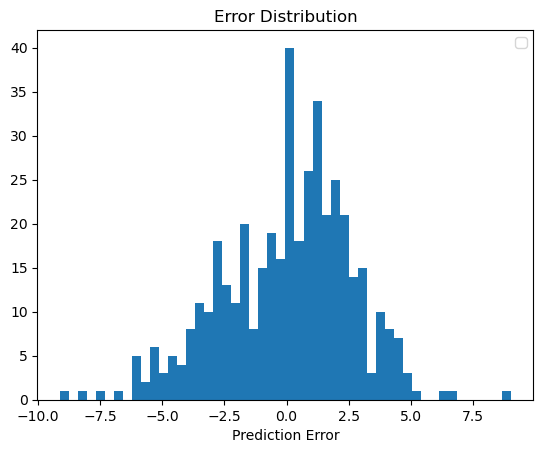

In [646]:
errors = np.abs(y_test - y_pred)

# Top 10 worst predictions
worst_indices = np.argsort(errors)[-10:][::-1]

print("Idx | Actual | Predicted | Error")
print("-" * 40)
for i in worst_indices:
    print(f"{i:4d} | {y_test[i]:7.4f} | {y_pred[i]:9.4f} | {errors[i]:.4f}")

# Error distribution plot
plt.hist(y_test - y_pred, bins=50)
plt.xlabel('Prediction Error')
plt.title('Error Distribution')
plt.legend()
plt.show()

### Feature Importance

In [647]:
zipped = zip(attributes, dt_reg_FGC_TL.feature_importances_)
zipped = sorted(zipped, key=lambda x: x[1], reverse=True)
for col, imp in zipped:
    print(col, imp)

FGC-FGC_CORE_CAL 0.4172692723600993
FGC-FGC_SR_CAL 0.2823352223893968
BIA-BIA_ECW 0.15064037434246555
BIA-BIA_TBW 0.05451010845170107
Physical-Height 0.04262044350720899
Physical-Weight 0.027564171795214438
Basic_Demos-Age 0.016757399268827248
Basic_Demos-Sex 0.008303007885086585


## ** TARGET VARIABLE SDS-SDS_Total_T

In [648]:
df_SDS_Total= df[[
'SDS-SDS_Total_T',
'Basic_Demos-Age','Basic_Demos-Sex', 'Physical-Weight',
'Physical-Height','BIA-BIA_FMI','BIA-BIA_FFMI',
]]




In [649]:
df_SDS_Total=df_SDS_Total.dropna()

In [650]:
df_SDS_Total.isnull().sum()

SDS-SDS_Total_T    0
Basic_Demos-Age    0
Basic_Demos-Sex    0
Physical-Weight    0
Physical-Height    0
BIA-BIA_FMI        0
BIA-BIA_FFMI       0
dtype: int64

### Partitioning

In [651]:
attributes = [col for col in df_SDS_Total.columns if col != 'SDS-SDS_Total_T']
X = df_SDS_Total[attributes].values
y = np.array(df_SDS_Total['SDS-SDS_Total_T'])

In [652]:
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.25, random_state=0)


In [653]:
print(X_train.shape, X_test.shape, y_train.shape, y_test.shape)

(1194, 6) (399, 6) (1194,) (399,)


In [654]:
df_SDS_Total.shape

(1593, 7)

### Randomized Search

In [314]:
# options for scoring
#scoring='neg_mean_squared_error'      # most common, minimizes large errors
#scoring='neg_mean_absolute_error'     # more robust to outliers
#scoring='neg_root_mean_squared_error' # directly in target units
#scoring='r2'                          # maximizes explained variance

In [315]:
param_list = {
    'max_depth': [None] + list(np.arange(10, 50)),
    'min_samples_split': [0.001, 0.002, 0.01, 0.05, 0.1, 0.2],
    'min_samples_leaf': [5, 10, 20, 30, 50, 100, 150],
    'criterion': ['squared_error', 'absolute_error', 'friedman_mse']  
}

dt_reg_SDS_Total = DecisionTreeRegressor()  

random_search = RandomizedSearchCV(
    DecisionTreeRegressor(),    
    param_distributions=param_list,
    cv=KFold(n_splits=5, shuffle=True, random_state=0), 
    scoring='neg_mean_squared_error' ,   
    n_jobs=-1,
    refit=True,
    n_iter=300,
)

random_search.fit(X_train, y_train)
dt_reg_SDS_Total = random_search.best_estimator_

In [655]:
param_list = {
    'n_estimators': [50, 100, 200, 300, 500],
    'max_depth': [None] + list(np.arange(2, 50)),
    'min_samples_split': [0.001, 0.002, 0.01, 0.05, 0.1, 0.2],
    'min_samples_leaf': [5, 10, 20, 30, 50, 100, 150],
    'criterion': ['squared_error', 'absolute_error', 'friedman_mse'],
    'max_features': ['sqrt', 'log2', None] # Optional: highly recommended to tune for RFs
}

dt_reg_SDS_Total = RandomForestRegressor(random_state=0)


random_search = RandomizedSearchCV(
    estimator=RandomForestRegressor(random_state=0),    
    param_distributions=param_list,
    cv=KFold(n_splits=5, shuffle=True, random_state=0), 
    scoring='neg_mean_squared_error',   
    n_jobs=-1,
    refit=True,
    n_iter=300,
    random_state=0 # Ensures the random search picks the same combinations on reruns
)

random_search.fit(X_train, y_train)
dt_reg_SDS_Total = random_search.best_estimator_

In [656]:
print(random_search.best_params_, random_search.best_score_)

{'n_estimators': 50, 'min_samples_split': 0.002, 'min_samples_leaf': 30, 'max_features': None, 'max_depth': 2, 'criterion': 'friedman_mse'} -174.615771318967


In [657]:
dt_reg_SDS_Total = random_search.best_estimator_
dt_reg_SDS_Total.fit(X_train, y_train)

RandomForestRegressor(criterion='friedman_mse', max_depth=2, max_features=None,
                      min_samples_leaf=30, min_samples_split=0.002,
                      n_estimators=50, random_state=0)

In [658]:
y_pred = dt_reg_SDS_Total.predict(X_test)

print(f"RMSE : {np.sqrt(mean_squared_error(y_test, y_pred)):.4f}") # Typical error
print(f"MAE  : {mean_absolute_error(y_test, y_pred):.4f}")  #Average Error
print(f"MSE  : {mean_squared_error(y_test, y_pred):.4f}")  #Average Error
print(f"R²   : {r2_score(y_test, y_pred):.4f}") # variance in the target variable

RMSE : 12.8319
MAE  : 10.0143
MSE  : 164.6576
R²   : 0.0154


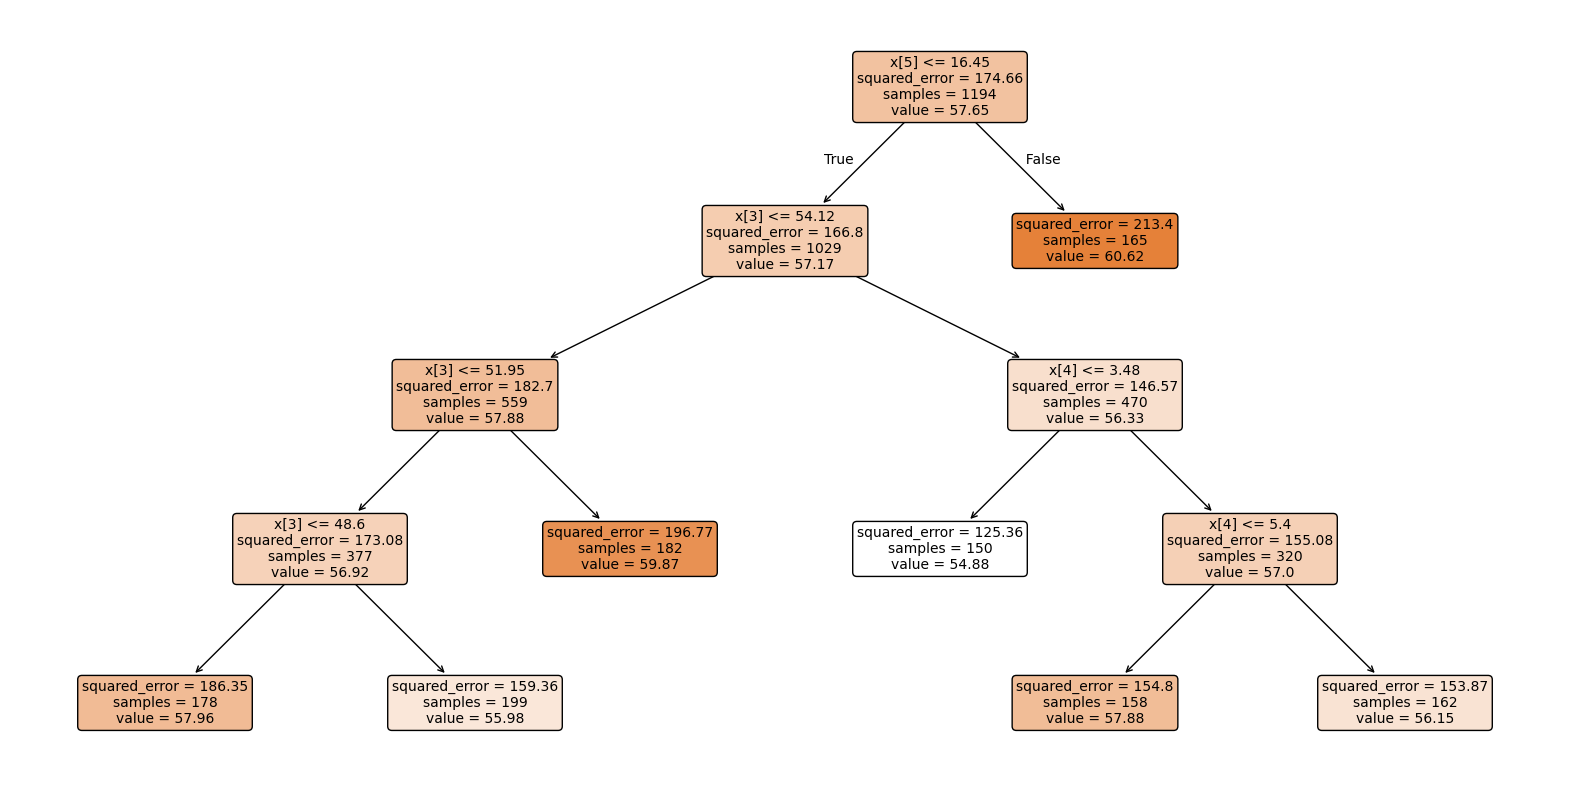

In [319]:
plt.figure(figsize=(20, 10))

plot_tree(
    dt_reg_SDS_Total,
    filled=True,
    rounded=True,
    fontsize=10,
    precision=2,
    max_depth = 4
)

plt.show()

Idx | Actual | Predicted | Error
----------------------------------------
 204 | 100.0000 |   57.2117 | 42.7883
 357 | 100.0000 |   57.3143 | 42.6857
 245 | 100.0000 |   57.4648 | 42.5352
  40 | 100.0000 |   57.4651 | 42.5349
 306 | 100.0000 |   57.9024 | 42.0976
 340 | 99.0000 |   58.1931 | 40.8069
 127 | 94.0000 |   55.8514 | 38.1486
 339 | 95.0000 |   58.4031 | 36.5969
 101 | 91.0000 |   57.4651 | 33.5349
 123 | 90.0000 |   56.9514 | 33.0486


C:\Users\paula\AppData\Local\Temp\ipykernel_11568\1016786874.py:15: UserWarning: No artists with labels found to put in legend.  Note that artists whose label start with an underscore are ignored when legend() is called with no argument.
  plt.legend()


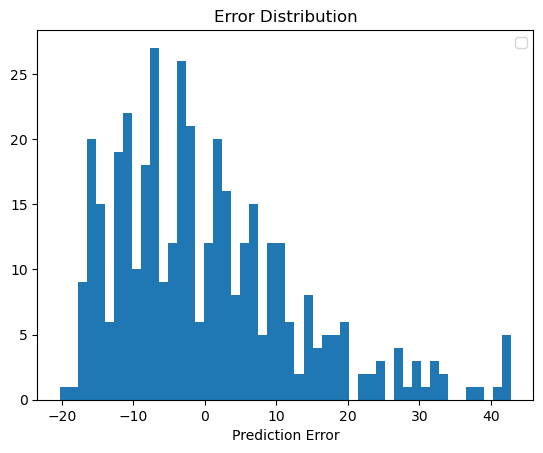

In [659]:
errors = np.abs(y_test - y_pred)

# Top 10 worst predictions
worst_indices = np.argsort(errors)[-10:][::-1]

print("Idx | Actual | Predicted | Error")
print("-" * 40)
for i in worst_indices:
    print(f"{i:4d} | {y_test[i]:7.4f} | {y_pred[i]:9.4f} | {errors[i]:.4f}")

# Error distribution plot
plt.hist(y_test - y_pred, bins=50)
plt.xlabel('Prediction Error')
plt.title('Error Distribution')
plt.legend()
plt.show()

### Feature Importance

In [660]:
zipped = zip(attributes, dt_reg_SDS_Total.feature_importances_)
zipped = sorted(zipped, key=lambda x: x[1], reverse=True)
for col, imp in zipped:
    print(col, imp)

BIA-BIA_FFMI 0.3848876449061599
Physical-Weight 0.2524083716401151
BIA-BIA_FMI 0.22311579884722094
Physical-Height 0.11535551546443056
Basic_Demos-Age 0.024232669142073674
Basic_Demos-Sex 0.0


## ** TARGET VARIABLE PreInt_EduHx-computerinternet_hoursday'

In [322]:
df_computerinternet= df[[
'Basic_Demos-Age', 'CGAS-CGAS_Score', 
       'Physical-Height', 'Physical-Weight', 'BIA-BIA_BMR',
       'Physical-HeartRate', 'FGC-FGC_TL',
       'BIA-BIA_Frame_num', 'BIA-BIA_SMM', 'BIA-BIA_TBW',
       'PreInt_EduHx-computerinternet_hoursday'
]]



In [323]:
df_computerinternet=df_computerinternet.dropna()

In [324]:
df_computerinternet.isnull().sum()

Basic_Demos-Age                           0
CGAS-CGAS_Score                           0
Physical-Height                           0
Physical-Weight                           0
BIA-BIA_BMR                               0
Physical-HeartRate                        0
FGC-FGC_TL                                0
BIA-BIA_Frame_num                         0
BIA-BIA_SMM                               0
BIA-BIA_TBW                               0
PreInt_EduHx-computerinternet_hoursday    0
dtype: int64

### Partitioning

In [325]:
attributes = [col for col in df_computerinternet.columns if col != 'PreInt_EduHx-computerinternet_hoursday']
X = df_computerinternet[attributes].values
y = np.array(df_computerinternet['PreInt_EduHx-computerinternet_hoursday'])

In [326]:
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.25, random_state=0)


In [327]:
print(X_train.shape, X_test.shape, y_train.shape, y_test.shape)

(1138, 10) (380, 10) (1138,) (380,)


In [328]:
df_computerinternet.shape

(1518, 11)

### Randomized Search

In [329]:
# options for scoring
#scoring='neg_mean_squared_error'      # most common, minimizes large errors
#scoring='neg_mean_absolute_error'     # more robust to outliers
#scoring='neg_root_mean_squared_error' # directly in target units
#scoring='r2'                          # maximizes explained variance

In [330]:
param_list = {
    'max_depth': [None] + list(np.arange(10, 50)),
    'min_samples_split': [0.001, 0.002, 0.01, 0.05, 0.1, 0.2],
    'min_samples_leaf': [5, 10, 20, 30, 50, 100, 150],
    'criterion': ['squared_error', 'absolute_error', 'friedman_mse']  
}

dt_reg_computerinternet = DecisionTreeRegressor()  

random_search = RandomizedSearchCV(
    DecisionTreeRegressor(),    
    param_distributions=param_list,
    cv=KFold(n_splits=5, shuffle=True, random_state=0), 
    scoring='neg_mean_squared_error' ,   
    n_jobs=-1,
    refit=True,
    n_iter=300,
)

random_search.fit(X_train, y_train)
dt_reg_computerinternet = random_search.best_estimator_

In [331]:
print(random_search.best_params_, random_search.best_score_)

{'min_samples_split': 0.1, 'min_samples_leaf': 150, 'max_depth': 18, 'criterion': 'squared_error'} -0.938830584832077


In [332]:
dt_reg_computerinternet = random_search.best_estimator_
dt_reg_computerinternet.fit(X_train, y_train)

DecisionTreeRegressor(max_depth=18, min_samples_leaf=150, min_samples_split=0.1)

In [333]:
y_pred = dt_reg_computerinternet.predict(X_test)

print(f"RMSE : {np.sqrt(mean_squared_error(y_test, y_pred)):.4f}") # Typical error
print(f"MAE  : {mean_absolute_error(y_test, y_pred):.4f}")  #Average Error
print(f"MSE  : {mean_squared_error(y_test, y_pred):.4f}")  #Average Error
print(f"R²   : {r2_score(y_test, y_pred):.4f}") # variance in the target variable

RMSE : 0.9412
MAE  : 0.8117
MSE  : 0.8859
R²   : 0.1583


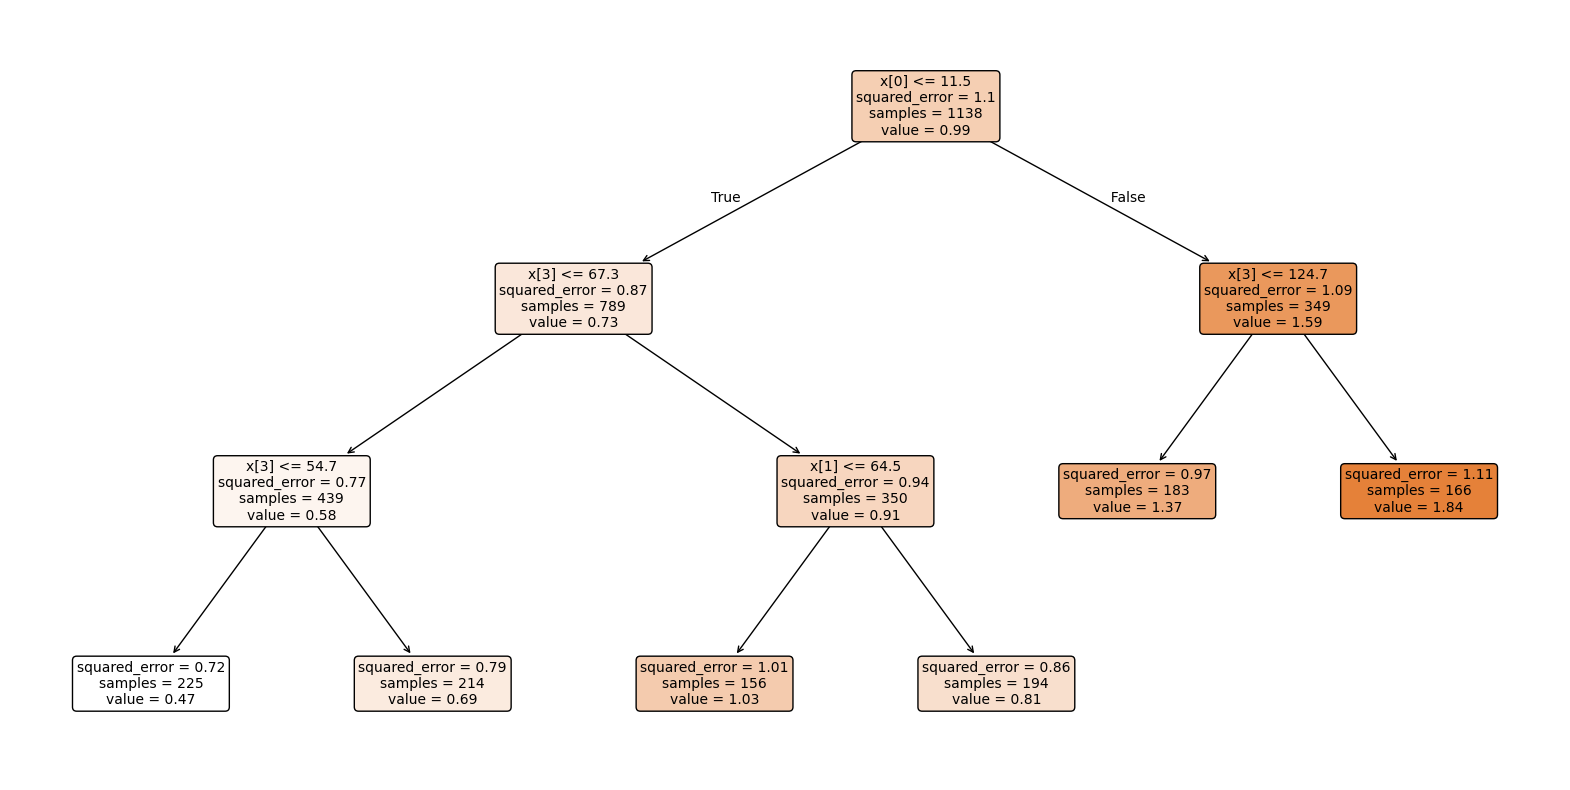

In [334]:
plt.figure(figsize=(20, 10))

plot_tree(
    dt_reg_computerinternet,
    filled=True,
    rounded=True,
    fontsize=10,
    precision=2,
    max_depth = 4
)

plt.show()

Idx | Actual | Predicted | Error
----------------------------------------
 291 |  3.0000 |    0.6916 | 2.3084
  29 |  3.0000 |    0.6916 | 2.3084
  31 |  3.0000 |    0.8144 | 2.1856
 134 |  3.0000 |    0.8144 | 2.1856
 190 |  3.0000 |    0.8144 | 2.1856
 122 |  3.0000 |    1.0321 | 1.9679
 315 |  3.0000 |    1.0321 | 1.9679
  39 |  3.0000 |    1.0321 | 1.9679
 345 |  3.0000 |    1.0321 | 1.9679
 188 |  0.0000 |    1.8373 | 1.8373


C:\Users\paula\AppData\Local\Temp\ipykernel_11568\1016786874.py:15: UserWarning: No artists with labels found to put in legend.  Note that artists whose label start with an underscore are ignored when legend() is called with no argument.
  plt.legend()


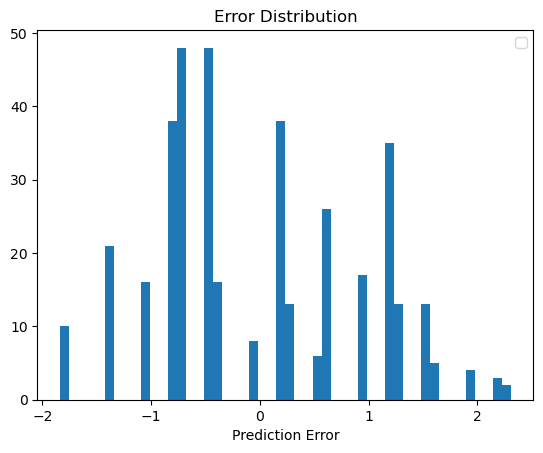

In [335]:
errors = np.abs(y_test - y_pred)

# Top 10 worst predictions
worst_indices = np.argsort(errors)[-10:][::-1]

print("Idx | Actual | Predicted | Error")
print("-" * 40)
for i in worst_indices:
    print(f"{i:4d} | {y_test[i]:7.4f} | {y_pred[i]:9.4f} | {errors[i]:.4f}")

# Error distribution plot
plt.hist(y_test - y_pred, bins=50)
plt.xlabel('Prediction Error')
plt.title('Error Distribution')
plt.legend()
plt.show()

### Feature Importance

In [336]:
zipped = zip(attributes, dt_reg_computerinternet.feature_importances_)
zipped = sorted(zipped, key=lambda x: x[1], reverse=True)
for col, imp in zipped:
    print(col, imp)

Basic_Demos-Age 0.784727451600078
Physical-Weight 0.19760068652452992
CGAS-CGAS_Score 0.017671861875392197
Physical-Height 0.0
BIA-BIA_BMR 0.0
Physical-HeartRate 0.0
FGC-FGC_TL 0.0
BIA-BIA_Frame_num 0.0
BIA-BIA_SMM 0.0
BIA-BIA_TBW 0.0


# IMPORT TOTAL DATASET

In [202]:
file_path = "../1.DATASET/CMI_V2.csv"
df_notna=pd.read_csv(file_path)
df_notna

,id,Basic_Demos-Age,Basic_Demos-Sex,CGAS-CGAS_Score,Physical-BMI,Physical-Height,Physical-Weight,BIA-BIA_BMR,Physical-HeartRate,Fitness_Endurance-Max_Stage,...,BIA-BIA_Frame_num,BIA-BIA_SMM,BIA-BIA_TBW,SDS-SDS_Total_T,PreInt_EduHx-computerinternet_hoursday,sii,Physical-MAP_CAL,FGC-FGC_CORE_CAL,FGC-FGC_GS_CAL,FGC-FGC_SR_CAL
0,0,5,0,51.0,16.877316,46.00,50.8,932.498000,NaN,5.0,...,1.0,19.541300,32.690900,NaN,3.0,2.0,82.152821,4.611111,17.883041,6.500000
1,1,9,0,NaN,14.035590,48.00,46.0,936.656000,70.0,NaN,...,1.0,15.410700,27.055200,64.0,0.0,0.0,90.666667,8.000000,18.204545,11.000000
2,2,10,1,71.0,16.648696,56.50,75.6,1115.380000,94.0,5.0,...,NaN,NaN,44.987000,54.0,2.0,0.0,82.333333,27.000000,12.450000,10.000000
3,3,9,0,71.0,18.292347,56.00,81.6,1131.430000,97.0,6.0,...,2.0,26.479800,45.996600,45.0,0.0,1.0,79.000000,23.000000,18.204545,7.000000
4,4,18,1,65.0,17.937682,NaN,77.0,NaN,NaN,NaN,...,2.0,NaN,NaN,NaN,1.0,0.0,90.152104,12.000000,26.463732,8.003205
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
8455,8455,7,1,NaN,16.130585,46.07,49.0,979.009933,82.5,2.5,...,1.0,NaN,31.583004,55.0,0.0,0.0,81.861037,6.500000,18.075000,7.000000
8456,8456,10,1,69.5,17.300000,56.13,47.8,1029.411546,80.5,5.0,...,1.0,22.983200,36.475662,NaN,0.0,1.0,79.833333,8.500000,13.575000,5.000000
8457,8457,10,1,70.0,40.937571,49.56,47.2,1034.387599,83.5,7.0,...,2.0,31.594712,35.106855,NaN,2.0,0.0,82.166667,21.500000,16.840263,9.500000
8458,8458,15,1,55.5,22.500000,63.79,99.5,1379.703447,87.5,NaN,...,2.0,46.467581,57.530686,NaN,1.0,2.0,88.395702,10.000000,26.417470,10.500000


In [203]:
df_notna.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 8460 entries, 0 to 8459
Data columns (total 32 columns):
 #   Column                                  Non-Null Count  Dtype  
---  ------                                  --------------  -----  
 0   id                                      8460 non-null   int64  
 1   Basic_Demos-Age                         8460 non-null   int64  
 2   Basic_Demos-Sex                         8460 non-null   int64  
 3   CGAS-CGAS_Score                         7034 non-null   float64
 4   Physical-BMI                            8460 non-null   float64
 5   Physical-Height                         7595 non-null   float64
 6   Physical-Weight                         7641 non-null   float64
 7   BIA-BIA_BMR                             6636 non-null   float64
 8   Physical-HeartRate                      7539 non-null   float64
 9   Fitness_Endurance-Max_Stage             5480 non-null   float64
 10  FGC-FGC_TL                              6945 non-null   floa

In [204]:
df_notna['BIA-BIA_BMR'].value_counts()

BIA-BIA_BMR
1115.380000    985
813.397000       5
1016.890000      2
1144.970000      2
1045.100000      2
              ... 
1311.730000      1
1615.670000      1
923.038000       1
978.827000       1
1015.199123      1
Name: count, Length: 5622, dtype: int64

In [205]:
df_notna['BIA-BIA_TBW'][df_notna['BIA-BIA_BMR']==1115.38].value_counts()

BIA-BIA_TBW
44.987    497
45.886      1
Name: count, dtype: int64

# REPLACE NULL VALUES

## 'Physical-Height'

In [206]:
attributes = ['id','Physical-BMI','Physical-Height', 'Physical-Weight']
df_unknown=df_notna[attributes][df_notna['Physical-Height'].isna()].copy()
df_unknown.isnull().sum()

id                   0
Physical-BMI         0
Physical-Height    865
Physical-Weight    260
dtype: int64

In [207]:
attributes = [col for col in df_unknown.columns if col not in ['Physical-Height','id']]
X_unknown = df_unknown[attributes].values
predicted_value = dt_reg_height.predict(X_unknown)

In [208]:
df_unknown['Physical-Height_DT'] = predicted_value
df_unknown=df_unknown[['id','Physical-Height_DT']]
df_unknown

,id,Physical-Height_DT
4,4,54.626000
26,26,59.125000
30,30,52.992857
35,35,50.722222
42,42,54.626000
...,...,...
8408,8408,63.500000
8435,8435,62.857143
8437,8437,69.750000
8447,8447,57.840000


In [209]:
df_notna=df_notna.merge(df_unknown,on=['id'],how="left")
df_notna.loc[((df_notna['Physical-Height'].isnull()) | (df_notna['Physical-Height']==0)) , 'Physical-Height'] = df_notna['Physical-Height_DT']
df_notna.isnull().sum()

id                                           0
Basic_Demos-Age                              0
Basic_Demos-Sex                              0
CGAS-CGAS_Score                           1426
Physical-BMI                                 0
Physical-Height                              0
Physical-Weight                            819
BIA-BIA_BMR                               1824
Physical-HeartRate                         921
Fitness_Endurance-Max_Stage               2980
FGC-FGC_TL                                1515
BIA-BIA_Activity_Level_num                1824
BIA-BIA_BMI                               1824
BIA-BIA_BMC                               1824
BIA-BIA_DEE                               1824
BIA-BIA_ECW                               1824
BIA-BIA_ICW                               1824
BIA-BIA_FFMI                              1824
BIA-BIA_FFM                               1824
BIA-BIA_FMI                               1824
BIA-BIA_Fat                               1824
BIA-BIA_LST  

## 'Physical-Weight'

In [210]:
df_notna.loc[((df_notna['Physical-Weight'].isnull())) , 'Physical-Weight'] = (df_notna['Physical-BMI']/703)*(df_notna['Physical-Height']*df_notna['Physical-Height'])

In [211]:
df_notna.isnull().sum()

id                                           0
Basic_Demos-Age                              0
Basic_Demos-Sex                              0
CGAS-CGAS_Score                           1426
Physical-BMI                                 0
Physical-Height                              0
Physical-Weight                              0
BIA-BIA_BMR                               1824
Physical-HeartRate                         921
Fitness_Endurance-Max_Stage               2980
FGC-FGC_TL                                1515
BIA-BIA_Activity_Level_num                1824
BIA-BIA_BMI                               1824
BIA-BIA_BMC                               1824
BIA-BIA_DEE                               1824
BIA-BIA_ECW                               1824
BIA-BIA_ICW                               1824
BIA-BIA_FFMI                              1824
BIA-BIA_FFM                               1824
BIA-BIA_FMI                               1824
BIA-BIA_Fat                               1824
BIA-BIA_LST  

## Physical-BMI

In [212]:
df_notna['Physical-BMI']=(df_notna['Physical-Weight']/(df_notna['Physical-Height']*df_notna['Physical-Height']))*703 

In [213]:
df_notna.isnull().sum()

id                                           0
Basic_Demos-Age                              0
Basic_Demos-Sex                              0
CGAS-CGAS_Score                           1426
Physical-BMI                                 0
Physical-Height                              0
Physical-Weight                              0
BIA-BIA_BMR                               1824
Physical-HeartRate                         921
Fitness_Endurance-Max_Stage               2980
FGC-FGC_TL                                1515
BIA-BIA_Activity_Level_num                1824
BIA-BIA_BMI                               1824
BIA-BIA_BMC                               1824
BIA-BIA_DEE                               1824
BIA-BIA_ECW                               1824
BIA-BIA_ICW                               1824
BIA-BIA_FFMI                              1824
BIA-BIA_FFM                               1824
BIA-BIA_FMI                               1824
BIA-BIA_Fat                               1824
BIA-BIA_LST  

## 'BIA-BIA-TBW'

In [214]:
attributes = ['id','BIA-BIA_TBW','BIA-BIA_ECW', 'BIA-BIA_ICW']
df_unknown=df_notna[attributes][(df_notna['BIA-BIA_TBW']==0) |(df_notna['BIA-BIA_TBW'].isna()) | (df_notna['BIA-BIA_TBW']==44.987)| (df_notna['BIA-BIA_TBW']>=df_notna['Physical-Weight'])].copy()
df_unknown.isnull().sum()

id                0
BIA-BIA_TBW    1824
BIA-BIA_ECW    1177
BIA-BIA_ICW    1156
dtype: int64

In [217]:
df_unknown=df_unknown.dropna(subset=['BIA-BIA_ECW', 'BIA-BIA_ICW'])
df_unknown.isnull().sum()

id               0
BIA-BIA_TBW    801
BIA-BIA_ECW      0
BIA-BIA_ICW      0
dtype: int64

In [218]:
attributes = [col for col in df_unknown.columns if col not in ['BIA-BIA_TBW','id']]
X_unknown = df_unknown[attributes].values
predicted_value = dt_reg_height.predict(X_unknown)

In [219]:
X_unknown.shape

(1118, 2)

In [220]:
df_unknown['BIA-BIA_TBW_DT'] = predicted_value
df_unknown=df_unknown[['id','BIA-BIA_TBW_DT']]
df_unknown

,id,BIA-BIA_TBW_DT
4,4,42.380000
13,13,42.380000
32,32,42.380000
34,34,42.380000
37,37,42.380000
...,...,...
8402,8402,41.616667
8405,8405,41.616667
8413,8413,42.500000
8437,8437,44.800000


In [221]:
df_notna=df_notna.merge(df_unknown,on=['id'],how="left")
df_notna.loc[((df_notna['BIA-BIA_TBW']==0) |(df_notna['BIA-BIA_TBW'].isna()) | (df_notna['BIA-BIA_TBW']==44.987)| (df_notna['BIA-BIA_TBW']>=df_notna['Physical-Weight'])) , 'BIA-BIA_TBW'] = df_notna['BIA-BIA_TBW_DT']
df_notna.isnull().sum()

id                                           0
Basic_Demos-Age                              0
Basic_Demos-Sex                              0
CGAS-CGAS_Score                           1426
Physical-BMI                                 0
Physical-Height                              0
Physical-Weight                              0
BIA-BIA_BMR                               1824
Physical-HeartRate                         921
Fitness_Endurance-Max_Stage               2980
FGC-FGC_TL                                1515
BIA-BIA_Activity_Level_num                1824
BIA-BIA_BMI                               1824
BIA-BIA_BMC                               1824
BIA-BIA_DEE                               1824
BIA-BIA_ECW                               1824
BIA-BIA_ICW                               1824
BIA-BIA_FFMI                              1824
BIA-BIA_FFM                               1824
BIA-BIA_FMI                               1824
BIA-BIA_Fat                               1824
BIA-BIA_LST  

## 'BIA-BIA_Fat'

In [178]:
attributes = ['id','Physical-Weight', 
                'Physical-Height','BIA-BIA_FMI',
                'BIA-BIA_Fat' ]
df_unknown=df_notna[attributes][(df_notna['BIA-BIA_Fat']==0) |(df_notna['BIA-BIA_Fat'].isna()) | (df_notna['BIA-BIA_Fat']==16.1746)| (df_notna['BIA-BIA_Fat']>=df_notna['Physical-Weight'])].copy()
df_unknown.isnull().sum()

id                    0
Physical-Weight       0
Physical-Height       0
BIA-BIA_FMI        1152
BIA-BIA_Fat        1824
dtype: int64

In [179]:
df_unknown=df_unknown.dropna(subset=['BIA-BIA_FMI'])
df_unknown.isnull().sum()

id                    0
Physical-Weight       0
Physical-Height       0
BIA-BIA_FMI           0
BIA-BIA_Fat        1180
dtype: int64

In [180]:
attributes = [col for col in df_unknown.columns if col not in ['BIA-BIA_Fat','id']]
X_unknown = df_unknown[attributes].values
predicted_value = dt_reg_FAT.predict(X_unknown)

In [181]:
X_unknown.shape

(1724, 3)

In [182]:
df_unknown['BIA-BIA_Fat_DT'] = predicted_value
df_unknown=df_unknown[['id','BIA-BIA_Fat_DT']]
df_unknown

,id,BIA-BIA_Fat_DT
2,2,15.74530
4,4,15.65890
8,8,15.65890
9,9,17.27510
11,11,15.65890
...,...,...
8425,8425,75.44290
8436,8436,9.16051
8450,8450,4.94494
8451,8451,43.51420


In [183]:
df_notna=df_notna.merge(df_unknown,on=['id'],how="left")
df_notna.loc[((df_notna['BIA-BIA_Fat']==0) |(df_notna['BIA-BIA_Fat'].isna()) | (df_notna['BIA-BIA_Fat']==16.1746)| (df_notna['BIA-BIA_Fat']>=df_notna['Physical-Weight'])), 'BIA-BIA_Fat'] = df_notna['BIA-BIA_Fat_DT']
df_notna.isnull().sum()

id                                           0
Basic_Demos-Age                              0
Basic_Demos-Sex                              0
CGAS-CGAS_Score                           1426
Physical-BMI                                 0
Physical-Height                              0
Physical-Weight                              0
BIA-BIA_BMR                               1824
Physical-HeartRate                         921
Fitness_Endurance-Max_Stage               2980
FGC-FGC_TL                                1515
BIA-BIA_Activity_Level_num                1824
BIA-BIA_BMI                               1824
BIA-BIA_BMC                               1824
BIA-BIA_DEE                               1824
BIA-BIA_ECW                               1824
BIA-BIA_ICW                               1824
BIA-BIA_FFMI                              1824
BIA-BIA_FFM                               1824
BIA-BIA_FMI                               1824
BIA-BIA_Fat                               1152
BIA-BIA_LST  

## BIA-BIA_DEE'

In [184]:
attributes = ['id','BIA-BIA_DEE',
    'BIA-BIA_BMR',                  
    'BIA-BIA_Activity_Level_num',   
    'Basic_Demos-Sex',
    'BIA-BIA_TBW'  ]
df_unknown=df_notna[attributes][(df_notna['BIA-BIA_DEE']==0) |(df_notna['BIA-BIA_DEE'].isna()) | (df_notna['BIA-BIA_DEE']==1863.98)].copy()
df_unknown.isnull().sum()

id                               0
BIA-BIA_DEE                   1824
BIA-BIA_BMR                   1132
BIA-BIA_Activity_Level_num    1166
Basic_Demos-Sex                  0
BIA-BIA_TBW                   1886
dtype: int64

In [185]:
df_unknown=df_unknown.dropna(subset=['BIA-BIA_BMR','BIA-BIA_TBW'])
df_unknown.isnull().sum()

id                              0
BIA-BIA_DEE                   611
BIA-BIA_BMR                     0
BIA-BIA_Activity_Level_num    173
Basic_Demos-Sex                 0
BIA-BIA_TBW                     0
dtype: int64

In [186]:
attributes = [col for col in df_unknown.columns if col not in ['BIA-BIA_DEE','id']]
X_unknown = df_unknown[attributes].values
predicted_value = dt_reg_DEE.predict(X_unknown)

In [187]:
X_unknown.shape

(678, 4)

In [188]:
df_unknown['BIA-BIA_DEE_DT'] = predicted_value
df_unknown=df_unknown[['id','BIA-BIA_DEE_DT']]
df_unknown

,id,BIA-BIA_DEE_DT
43,43,1894.600000
71,71,1785.655000
105,105,1894.600000
126,126,1785.655000
154,154,1894.600000
...,...,...
8415,8415,1739.575000
8416,8416,1713.164000
8417,8417,1839.456667
8434,8434,2410.616000


In [189]:
df_notna=df_notna.merge(df_unknown,on=['id'],how="left")
df_notna.loc[((df_notna['BIA-BIA_DEE']==0) |(df_notna['BIA-BIA_DEE'].isna()) | (df_notna['BIA-BIA_DEE']==1863.98)), 'BIA-BIA_DEE'] = df_notna['BIA-BIA_DEE_DT']
df_notna.isnull().sum()

id                                           0
Basic_Demos-Age                              0
Basic_Demos-Sex                              0
CGAS-CGAS_Score                           1426
Physical-BMI                                 0
Physical-Height                              0
Physical-Weight                              0
BIA-BIA_BMR                               1824
Physical-HeartRate                         921
Fitness_Endurance-Max_Stage               2980
FGC-FGC_TL                                1515
BIA-BIA_Activity_Level_num                1824
BIA-BIA_BMI                               1824
BIA-BIA_BMC                               1824
BIA-BIA_DEE                               2131
BIA-BIA_ECW                               1824
BIA-BIA_ICW                               1824
BIA-BIA_FFMI                              1824
BIA-BIA_FFM                               1824
BIA-BIA_FMI                               1824
BIA-BIA_Fat                               1152
BIA-BIA_LST  

## 'BIA-BIA_BMC'

In [190]:
attributes = ['id','BIA-BIA_LST' ,
'BIA-BIA_ICW',
'BIA-BIA_BMR' ,
'BIA-BIA_BMC']
df_unknown=df_notna[attributes][(df_notna['BIA-BIA_BMC']<=0) |(df_notna['BIA-BIA_BMC'].isna()) | (df_notna['BIA-BIA_BMC']==3.92272)].copy()
df_unknown.isnull().sum()

id                0
BIA-BIA_LST    1129
BIA-BIA_ICW    1152
BIA-BIA_BMR    1171
BIA-BIA_BMC    1824
dtype: int64

In [191]:
df_unknown=df_unknown.dropna(subset=['BIA-BIA_BMR','BIA-BIA_ICW'])
df_unknown.isnull().sum()

id               0
BIA-BIA_LST    368
BIA-BIA_ICW      0
BIA-BIA_BMR      0
BIA-BIA_BMC    784
dtype: int64

In [192]:
attributes = [col for col in df_unknown.columns if col not in ['BIA-BIA_BMC','id']]
X_unknown = df_unknown[attributes].values
predicted_value = dt_reg_BMC.predict(X_unknown)

In [193]:
X_unknown.shape

(1077, 3)

In [194]:
df_unknown['BIA-BIA_BMC_DT'] = predicted_value
df_unknown=df_unknown[['id','BIA-BIA_BMC_DT']]
df_unknown

,id,BIA-BIA_BMC_DT
11,11,3.433297
14,14,3.433297
16,16,3.433297
23,23,3.433297
30,30,3.433297
...,...,...
8425,8425,3.219643
8449,8449,2.729543
8452,8452,7.918304
8458,8458,4.916971


In [195]:
df_notna=df_notna.merge(df_unknown,on=['id'],how="left")
df_notna.loc[((df_notna['BIA-BIA_BMC']<=0) |(df_notna['BIA-BIA_BMC'].isna()) | (df_notna['BIA-BIA_BMC']==3.92272)), 'BIA-BIA_BMC'] = df_notna['BIA-BIA_BMC_DT']
df_notna.isnull().sum()

id                                           0
Basic_Demos-Age                              0
Basic_Demos-Sex                              0
CGAS-CGAS_Score                           1426
Physical-BMI                                 0
Physical-Height                              0
Physical-Weight                              0
BIA-BIA_BMR                               1824
Physical-HeartRate                         921
Fitness_Endurance-Max_Stage               2980
FGC-FGC_TL                                1515
BIA-BIA_Activity_Level_num                1824
BIA-BIA_BMI                               1824
BIA-BIA_BMC                               1766
BIA-BIA_DEE                               2131
BIA-BIA_ECW                               1824
BIA-BIA_ICW                               1824
BIA-BIA_FFMI                              1824
BIA-BIA_FFM                               1824
BIA-BIA_FMI                               1824
BIA-BIA_Fat                               1152
BIA-BIA_LST  

## 'BIA-BIA_SMM'

In [198]:
attributes = ['id','BIA-BIA_LST',
'BIA-BIA_ICW',
'BIA-BIA_FFM',
'BIA-BIA_SMM' ]
df_unknown=df_notna[attributes][(df_notna['BIA-BIA_SMM']==0) |(df_notna['BIA-BIA_SMM'].isna()) | (df_notna['BIA-BIA_SMM']==27.4151)| (df_notna['BIA-BIA_SMM']>=df_notna['BIA-BIA_FFM'])].copy()
df_unknown.isnull().sum()

id                0
BIA-BIA_LST    1161
BIA-BIA_ICW    1158
BIA-BIA_FFM    1138
BIA-BIA_SMM    1824
dtype: int64

In [199]:
df_unknown=df_unknown.dropna(subset=['BIA-BIA_ICW',])
df_unknown.isnull().sum()

id                0
BIA-BIA_LST     646
BIA-BIA_ICW       0
BIA-BIA_FFM     598
BIA-BIA_SMM    1165
dtype: int64

In [ ]:
attributes = [col for col in df_unknown.columns if col not in ['BIA-BIA_Fat','id']]
X_unknown = df_unknown[attributes].values
predicted_value = dt_reg_FAT.predict(X_unknown)

In [ ]:
X_unknown.shape

(1724, 3)

In [ ]:
df_unknown['BIA-BIA_Fat_DT'] = predicted_value
df_unknown=df_unknown[['id','BIA-BIA_Fat_DT']]
df_unknown

,id,BIA-BIA_Fat_DT
2,2,15.74530
4,4,15.65890
8,8,15.65890
9,9,17.27510
11,11,15.65890
...,...,...
8425,8425,75.44290
8436,8436,9.16051
8450,8450,4.94494
8451,8451,43.51420


In [ ]:
df_notna=df_notna.merge(df_unknown,on=['id'],how="left")
df_notna.loc[((df_notna['BIA-BIA_Fat']==0) |(df_notna['BIA-BIA_Fat'].isna()) | (df_notna['BIA-BIA_Fat']==16.1746)| (df_notna['BIA-BIA_Fat']>=df_notna['Physical-Weight'])), 'BIA-BIA_Fat'] = df_notna['BIA-BIA_Fat_DT']
df_notna.isnull().sum()

id                                           0
Basic_Demos-Age                              0
Basic_Demos-Sex                              0
CGAS-CGAS_Score                           1426
Physical-BMI                                 0
Physical-Height                              0
Physical-Weight                              0
BIA-BIA_BMR                               1824
Physical-HeartRate                         921
Fitness_Endurance-Max_Stage               2980
FGC-FGC_TL                                1515
BIA-BIA_Activity_Level_num                1824
BIA-BIA_BMI                               1824
BIA-BIA_BMC                               1824
BIA-BIA_DEE                               1824
BIA-BIA_ECW                               1824
BIA-BIA_ICW                               1824
BIA-BIA_FFMI                              1824
BIA-BIA_FFM                               1824
BIA-BIA_FMI                               1824
BIA-BIA_Fat                               1152
BIA-BIA_LST  

# not null dataset 

In [152]:
df_notna.shape

(8460, 34)

In [95]:
df_notna=df_notna.drop(columns = 
  ['Physical-Height_DT'])

In [96]:
df_notna.columns



Index(['id', 'Basic_Demos-Age', 'Basic_Demos-Sex', 'CGAS-CGAS_Score',
       'Physical-BMI', 'Physical-Height', 'Physical-Weight',
       'Physical-HeartRate', 'Fitness_Endurance-Max_Stage', 'FGC-FGC_TL',
       'BIA-BIA_Activity_Level_num', 'BIA-BIA_BMI', 'BIA-BIA_BMC',
       'BIA-BIA_DEE', 'BIA-BIA_ECW', 'BIA-BIA_ICW', 'BIA-BIA_FFMI',
       'BIA-BIA_FFM', 'BIA-BIA_FMI', 'BIA-BIA_Fat', 'BIA-BIA_LST',
       'BIA-BIA_Frame_num', 'BIA-BIA_SMM', 'BIA-BIA_TBW', 'SDS-SDS_Total_T',
       'PreInt_EduHx-computerinternet_hoursday', 'sii', 'Physical-MAP_CAL',
       'FGC-FGC_CORE_CAL', 'FGC-FGC_GS_CAL', 'FGC-FGC_SR_CAL'],
      dtype='object')

In [97]:
df_notna.to_csv('../1.DATASET/CMI_NN_V1.csv', index=False)